In [ ]:
# =========================================================
# Full baseline code
# - Recursive image search
# - Ignore Labels.json
# - Train from scratch/fine-tune from ImageNet pretrained
# - Validate on clean val
# - Evaluate on 4 noise types:
#     1) Gaussian
#     2) Speckle
#     3) Salt-and-Pepper
#     4) Poisson
# - Save best model
# =========================================================

import os
import random
import numpy as np
from PIL import Image
from collections import Counter
from typing import List, Tuple, Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

# =========================
# Config
# =========================
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_ROOT = "/kaggle/input/datasets/ambityga/imagenet100"   # <- 수정
TRAIN_DIRS = [
    os.path.join(DATASET_ROOT, "train.X1"),
    os.path.join(DATASET_ROOT, "train.X2"),
    os.path.join(DATASET_ROOT, "train.X3"),
    os.path.join(DATASET_ROOT, "train.X4"),
]
VAL_DIR = os.path.join(DATASET_ROOT, "val.X")

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4

SAVE_PATH = "/kaggle/working/baseline_resnet18_best.pth"

CLASS_NAMES = [
    "n01440764", "n01484850", "n01494475", "n01531178", "n01632777",
    "n01665541", "n01687978", "n01695060", "n01749939", "n01775062",
    "n01795545", "n01818515", "n01820546", "n01824575", "n01833805",
    "n01914609", "n01924916", "n01930112", "n01950731", "n01978455",
    "n01984695", "n02007558", "n02012849", "n02018795", "n02037110"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPEG", ".JPG", ".PNG")

# Noise severities
GAUSSIAN_SIGMAS = [0.02, 0.05, 0.10]
SPECKLE_SIGMAS  = [0.05, 0.10]
SP_AMOUNTS      = [0.02, 0.05]
POISSON_SCALES  = [1, 2]

# =========================
# Reproducibility
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================
# File discovery / labeling
# =========================
def find_all_images(root: str) -> List[str]:
    image_paths = []
    if not os.path.exists(root):
        return image_paths

    for cur_root, _, files in os.walk(root):
        for fname in files:
            if fname.endswith(VALID_EXTS):
                image_paths.append(os.path.join(cur_root, fname))
    return sorted(image_paths)

def infer_label_from_path(path: str) -> Optional[int]:
    """
    경로의 모든 디렉토리 이름 중 CLASS_NAMES가 있으면 그걸 라벨로 사용
    예: train.X1/n01440764/sub/a.jpg -> n01440764
    """
    parts = os.path.normpath(path).split(os.sep)
    for p in parts:
        if p in CLASS_TO_IDX:
            return CLASS_TO_IDX[p]
    return None

# =========================
# Noise functions
# =========================
def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + noise, 0.0, 1.0)

def add_speckle_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + x * noise, 0.0, 1.0)

def add_salt_pepper_noise(x: torch.Tensor, amount: float) -> torch.Tensor:
    y = x.clone()
    c, h, w = y.shape
    total = h * w
    num = int(total * amount)
    if num <= 0:
        return y

    coords = torch.randint(0, total, (num,), device=y.device)
    ys = coords // w
    xs = coords % w
    half = num // 2

    y[:, ys[:half], xs[:half]] = 1.0
    y[:, ys[half:], xs[half:]] = 0.0
    return y

def add_poisson_noise(x: torch.Tensor, scale: float = 1.0) -> torch.Tensor:
    vals = torch.clamp(x * 255.0 * scale, min=1.0)
    noisy = torch.poisson(vals) / (255.0 * scale)
    return torch.clamp(noisy, 0.0, 1.0)

def apply_noise(x: torch.Tensor, noise_type: str, severity: float) -> torch.Tensor:
    if noise_type == "clean":
        return x
    elif noise_type == "gaussian":
        return add_gaussian_noise(x, severity)
    elif noise_type == "speckle":
        return add_speckle_noise(x, severity)
    elif noise_type == "salt_pepper":
        return add_salt_pepper_noise(x, severity)
    elif noise_type == "poisson":
        return add_poisson_noise(x, severity)
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")

# =========================
# Dataset
# =========================
class RecursiveImageDataset(Dataset):
    def __init__(
        self,
        roots: List[str],
        img_size: int = 224,
        train: bool = True,
        noise_type: str = "clean",
        severity: float = 0.0,
    ):
        self.roots = roots
        self.train = train
        self.noise_type = noise_type
        self.severity = severity
        self.samples: List[Tuple[str, int]] = []

        for root in roots:
            for path in find_all_images(root):
                label = infer_label_from_path(path)
                if label is not None:
                    self.samples.append((path, label))

        if len(self.samples) == 0:
            raise RuntimeError(
                "라벨이 붙은 이미지가 하나도 없습니다. "
                "경로 안에 n01440764 같은 클래스 폴더명이 실제로 포함되어 있는지 확인하세요."
            )

        if train:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.RandomHorizontalFlip(),
                T.ToTensor(),
            ])
        else:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)

        if (not self.train) or (self.noise_type != "clean"):
            x = apply_noise(x, self.noise_type, self.severity)

        return x, label, path

# =========================
# Model
# =========================
def build_model(num_classes: int):
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# =========================
# Train / Eval
# =========================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), 100.0 * correct / max(total, 1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / max(total, 1)

# =========================
# Build datasets
# =========================
train_ds = RecursiveImageDataset(
    roots=TRAIN_DIRS,
    img_size=IMG_SIZE,
    train=True,
    noise_type="clean",
    severity=0.0,
)

val_clean_ds = RecursiveImageDataset(
    roots=[VAL_DIR],
    img_size=IMG_SIZE,
    train=False,
    noise_type="clean",
    severity=0.0,
)

print("=" * 80)
print("DEVICE:", DEVICE)
print("NUM_CLASSES:", NUM_CLASSES)
print("Train samples:", len(train_ds))
print("Val samples:", len(val_clean_ds))
print("=" * 80)

train_label_counts = Counter([y for _, y in train_ds.samples])
val_label_counts = Counter([y for _, y in val_clean_ds.samples])

print("Train class counts:")
for i in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[i]}: {train_label_counts.get(i, 0)}")

print("\nVal class counts:")
for i in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[i]}: {val_label_counts.get(i, 0)}")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_clean_loader = DataLoader(
    val_clean_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# =========================
# Train
# =========================
model = build_model(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_acc = 0.0
best_state = None

print("\nStarting training...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_acc = evaluate(model, val_clean_loader)

    print(f"[Epoch {epoch:02d}] "
          f"train_loss={train_loss:.4f} | "
          f"train_acc={train_acc:.2f} | "
          f"val_clean_acc={val_acc:.2f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(best_state, SAVE_PATH)
        print(f"  -> Best model saved to {SAVE_PATH}")

print(f"\nBest clean val acc: {best_val_acc:.2f}")

if best_state is not None:
    model.load_state_dict(best_state)

# =========================
# Multi-noise evaluation
# =========================
eval_settings = [("clean", 0.0)]
eval_settings += [("gaussian", s) for s in GAUSSIAN_SIGMAS]
eval_settings += [("speckle", s) for s in SPECKLE_SIGMAS]
eval_settings += [("salt_pepper", s) for s in SP_AMOUNTS]
eval_settings += [("poisson", s) for s in POISSON_SCALES]

results = []

print("\nStarting noise evaluation...\n")
for noise_type, severity in eval_settings:
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    acc = evaluate(model, loader)
    results.append((noise_type, severity, acc))
    print(f"[Baseline] noise={noise_type:12s} severity={severity:<5} | acc={acc:.2f}")

print("\n" + "=" * 80)
print("Final Summary")
print("=" * 80)
for noise_type, severity, acc in results:
    print(f"{noise_type:12s} | severity={severity:<5} | acc={acc:.2f}")

print(f"\nBest model saved at: {SAVE_PATH}")

In [ ]:
# =========================================================
# Tune AdaptThr threshold (ALPHA) using saved model in /kaggle/working
# - recursive dataset search
# - ignore Labels.json
# - auto-load model from /kaggle/working
# - find best alpha on noisy validation conditions
# - final comparison: baseline vs tuned AdaptThr
# =========================================================

import os
import random
import numpy as np
from PIL import Image
from typing import List, Tuple, Optional
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

# =========================
# Config
# =========================
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_ROOT = "/kaggle/input/datasets/ambityga/imagenet100"   # <- 수정
VAL_DIR = os.path.join(DATASET_ROOT, "val.X")

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2

# /kaggle/working 안에서 자동 탐색할 모델 파일명 후보
MODEL_CANDIDATES = [
    "/kaggle/working/baseline_resnet18_best.pth",
    "/kaggle/working/baseline_resnet18_final.pth",
    "/kaggle/working/adaptthr_resnet18_best.pth",
]

CLASS_NAMES = [
    "n01440764", "n01484850", "n01494475", "n01531178", "n01632777",
    "n01665541", "n01687978", "n01695060", "n01749939", "n01775062",
    "n01795545", "n01818515", "n01820546", "n01824575", "n01833805",
    "n01914609", "n01924916", "n01930112", "n01950731", "n01978455",
    "n01984695", "n02007558", "n02012849", "n02018795", "n02037110"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPEG", ".JPG", ".PNG")

# Noise settings
GAUSSIAN_SIGMAS = [0.02, 0.05, 0.10]
SPECKLE_SIGMAS  = [0.05, 0.10]
SP_AMOUNTS      = [0.02, 0.05]
POISSON_SCALES  = [1, 2]

# alpha 후보
ALPHA_CANDIDATES = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
RING_RATIO = 0.18
USE_PER_CHANNEL_TAU = True

# 튜닝 시 사용할 noisy 조건
TUNE_SETTINGS = [
    ("gaussian", 0.02),
    ("gaussian", 0.05),
    ("gaussian", 0.10),
    ("speckle", 0.05),
    ("speckle", 0.10),
    ("salt_pepper", 0.02),
    ("poisson", 1),
]

# 최종 보고용
FINAL_SETTINGS = [("clean", 0.0)]
FINAL_SETTINGS += [("gaussian", s) for s in GAUSSIAN_SIGMAS]
FINAL_SETTINGS += [("speckle", s) for s in SPECKLE_SIGMAS]
FINAL_SETTINGS += [("salt_pepper", s) for s in SP_AMOUNTS]
FINAL_SETTINGS += [("poisson", s) for s in POISSON_SCALES]

# =========================
# Seed
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================
# File discovery / labeling
# =========================
def find_all_images(root: str) -> List[str]:
    image_paths = []
    if not os.path.exists(root):
        return image_paths
    for cur_root, _, files in os.walk(root):
        for fname in files:
            if fname.endswith(VALID_EXTS):
                image_paths.append(os.path.join(cur_root, fname))
    return sorted(image_paths)

def infer_label_from_path(path: str) -> Optional[int]:
    parts = os.path.normpath(path).split(os.sep)
    for p in parts:
        if p in CLASS_TO_IDX:
            return CLASS_TO_IDX[p]
    return None

# =========================
# Noise
# =========================
def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + noise, 0.0, 1.0)

def add_speckle_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + x * noise, 0.0, 1.0)

def add_salt_pepper_noise(x: torch.Tensor, amount: float) -> torch.Tensor:
    y = x.clone()
    c, h, w = y.shape
    total = h * w
    num = int(total * amount)
    if num <= 0:
        return y
    coords = torch.randint(0, total, (num,), device=y.device)
    ys = coords // w
    xs = coords % w
    half = num // 2
    y[:, ys[:half], xs[:half]] = 1.0
    y[:, ys[half:], xs[half:]] = 0.0
    return y

def add_poisson_noise(x: torch.Tensor, scale: float = 1.0) -> torch.Tensor:
    vals = torch.clamp(x * 255.0 * scale, min=1.0)
    noisy = torch.poisson(vals) / (255.0 * scale)
    return torch.clamp(noisy, 0.0, 1.0)

def apply_noise(x: torch.Tensor, noise_type: str, severity: float) -> torch.Tensor:
    if noise_type == "clean":
        return x
    elif noise_type == "gaussian":
        return add_gaussian_noise(x, severity)
    elif noise_type == "speckle":
        return add_speckle_noise(x, severity)
    elif noise_type == "salt_pepper":
        return add_salt_pepper_noise(x, severity)
    elif noise_type == "poisson":
        return add_poisson_noise(x, severity)
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")

# =========================
# Dataset
# =========================
class RecursiveImageDataset(Dataset):
    def __init__(
        self,
        roots: List[str],
        img_size: int = 224,
        train: bool = False,
        noise_type: str = "clean",
        severity: float = 0.0,
    ):
        self.samples: List[Tuple[str, int]] = []
        self.train = train
        self.noise_type = noise_type
        self.severity = severity

        for root in roots:
            for path in find_all_images(root):
                label = infer_label_from_path(path)
                if label is not None:
                    self.samples.append((path, label))

        if len(self.samples) == 0:
            raise RuntimeError("라벨이 붙은 이미지를 찾지 못했습니다. 폴더 구조를 확인하세요.")

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        x = apply_noise(x, self.noise_type, self.severity)
        return x, label, path

# =========================
# Model
# =========================
def build_model(num_classes: int):
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def auto_find_model_path():
    for p in MODEL_CANDIDATES:
        if os.path.exists(p):
            return p

    # fallback: /kaggle/working 내 pth 파일 아무거나
    for fname in os.listdir("/kaggle/working"):
        if fname.endswith(".pth"):
            return os.path.join("/kaggle/working", fname)

    raise FileNotFoundError("/kaggle/working 안에서 모델 .pth 파일을 찾지 못했습니다.")

# =========================
# AdaptThr
# =========================
def build_high_freq_ring_mask(h: int, w: int, ring_ratio: float, device):
    yy, xx = torch.meshgrid(
        torch.arange(h, device=device),
        torch.arange(w, device=device),
        indexing="ij"
    )
    cy, cx = h // 2, w // 2
    dist = torch.sqrt((yy - cy).float() ** 2 + (xx - cx).float() ** 2)
    max_r = float(min(cy, cx))
    inner = max_r * (1.0 - ring_ratio)
    return (dist >= inner) & (dist <= max_r)

def robust_sigma_from_ring(mag_shifted: torch.Tensor, ring_mask: torch.Tensor) -> torch.Tensor:
    ring_vals = mag_shifted[..., ring_mask]                 # [B,C,N]
    med = ring_vals.median(dim=-1, keepdim=True).values
    mad = (ring_vals - med).abs().median(dim=-1).values
    sigma_hat = mad / 0.6745
    return sigma_hat                                        # [B,C]

def adaptthr_batch(
    x: torch.Tensor,
    alpha: float,
    ring_ratio: float = 0.18,
    use_per_channel_tau: bool = True,
) -> torch.Tensor:
    B, C, H, W = x.shape
    x_fft = torch.fft.fft2(x, dim=(-2, -1))
    x_fft_shift = torch.fft.fftshift(x_fft, dim=(-2, -1))

    mag = torch.abs(x_fft_shift)
    phase = torch.angle(x_fft_shift)

    ring_mask = build_high_freq_ring_mask(H, W, ring_ratio, x.device)
    sigma_hat = robust_sigma_from_ring(mag, ring_mask)      # [B,C]

    if use_per_channel_tau:
        tau = alpha * sigma_hat                             # [B,C]
    else:
        tau = alpha * sigma_hat.mean(dim=1, keepdim=True)   # [B,1]

    tau = tau[..., None, None]
    mag_thr = torch.clamp(mag - tau, min=0.0)

    real = mag_thr * torch.cos(phase)
    imag = mag_thr * torch.sin(phase)
    x_fft_thr_shift = torch.complex(real, imag)

    x_fft_thr = torch.fft.ifftshift(x_fft_thr_shift, dim=(-2, -1))
    x_rec = torch.fft.ifft2(x_fft_thr, dim=(-2, -1)).real
    return torch.clamp(x_rec, 0.0, 1.0)

# =========================
# Eval
# =========================
@torch.no_grad()
def evaluate(model, loader, alpha: Optional[float] = None):
    model.eval()
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if alpha is not None:
            images = adaptthr_batch(
                images,
                alpha=alpha,
                ring_ratio=RING_RATIO,
                use_per_channel_tau=USE_PER_CHANNEL_TAU,
            )

        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / max(total, 1)

# =========================
# Load model
# =========================
model_path = auto_find_model_path()
print("Using model:", model_path)

model = build_model(NUM_CLASSES).to(DEVICE)
ckpt = torch.load(model_path, map_location=DEVICE)

if isinstance(ckpt, dict) and "state_dict" in ckpt:
    ckpt = ckpt["state_dict"]

new_ckpt = {}
for k, v in ckpt.items():
    new_ckpt[k.replace("module.", "")] = v

missing, unexpected = model.load_state_dict(new_ckpt, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

# =========================
# Dataset info
# =========================
val_clean_ds = RecursiveImageDataset(
    roots=[VAL_DIR],
    img_size=IMG_SIZE,
    train=False,
    noise_type="clean",
    severity=0.0,
)
print("Val samples:", len(val_clean_ds))

label_counts = Counter([y for _, y in val_clean_ds.samples])
print("Val class counts:")
for i in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[i]}: {label_counts.get(i, 0)}")

# =========================
# Tune alpha
# =========================
print("\n" + "=" * 80)
print("Tuning ALPHA")
print("=" * 80)

alpha_results = []

for alpha in ALPHA_CANDIDATES:
    accs = []
    print(f"\n[Alpha = {alpha}]")

    for noise_type, severity in TUNE_SETTINGS:
        ds = RecursiveImageDataset(
            roots=[VAL_DIR],
            img_size=IMG_SIZE,
            train=False,
            noise_type=noise_type,
            severity=severity,
        )
        loader = DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        acc = evaluate(model, loader, alpha=alpha if alpha > 0 else None)
        accs.append(acc)
        print(f"  {noise_type:12s} severity={severity:<5} | acc={acc:.2f}")

    mean_acc = float(np.mean(accs))
    alpha_results.append((alpha, mean_acc))
    print(f"  -> mean noisy acc = {mean_acc:.2f}")

best_alpha, best_mean = max(alpha_results, key=lambda x: x[1])

print("\n" + "=" * 80)
print("Alpha tuning summary")
print("=" * 80)
for alpha, mean_acc in alpha_results:
    print(f"alpha={alpha:<4} | mean_noisy_acc={mean_acc:.2f}")

print(f"\nBest alpha: {best_alpha}")
print(f"Best mean noisy acc: {best_mean:.2f}")

# =========================
# Final comparison
# =========================
print("\n" + "=" * 80)
print("Final Comparison: Baseline vs Tuned AdaptThr")
print("=" * 80)

rows = []

for noise_type, severity in FINAL_SETTINGS:
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    baseline_acc = evaluate(model, loader, alpha=None)
    tuned_acc = evaluate(model, loader, alpha=best_alpha if best_alpha > 0 else None)
    delta = tuned_acc - baseline_acc

    rows.append((noise_type, severity, baseline_acc, tuned_acc, delta))
    print(f"{noise_type:12s} | severity={severity:<5} | baseline={baseline_acc:.2f} | tuned={tuned_acc:.2f} | delta={delta:+.2f}")

# =========================
# Save CSV
# =========================
import pandas as pd

df = pd.DataFrame(rows, columns=["noise", "severity", "baseline_acc", "tuned_adaptthr_acc", "delta"])
save_csv = "/kaggle/working/tuned_adaptthr_results.csv"
df.to_csv(save_csv, index=False)

alpha_df = pd.DataFrame(alpha_results, columns=["alpha", "mean_noisy_acc"])
alpha_csv = "/kaggle/working/alpha_tuning_results.csv"
alpha_df.to_csv(alpha_csv, index=False)

print("\nSaved:")
print(save_csv)
print(alpha_csv)
print("\nFinal table:")
print(df)

In [ ]:
# =========================================================
# EXP 1: alpha vs clean / mean noisy
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

ALPHA_GRID = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2]

TUNE_SETTINGS = [
    ("gaussian", 0.02),
    ("gaussian", 0.05),
    ("gaussian", 0.10),
    ("speckle", 0.05),
    ("speckle", 0.10),
    ("salt_pepper", 0.02),
    ("salt_pepper", 0.05),
    ("poisson", 1),
    ("poisson", 2),
]

def build_loader(noise_type, severity):
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

# clean loader
clean_loader = build_loader("clean", 0.0)

rows = []

for alpha in ALPHA_GRID:
    # clean
    clean_acc = evaluate(model, clean_loader, alpha=None if alpha == 0.0 else alpha)

    # noisy mean
    noisy_accs = []
    for noise_type, severity in TUNE_SETTINGS:
        loader = build_loader(noise_type, severity)
        acc = evaluate(model, loader, alpha=None if alpha == 0.0 else alpha)
        noisy_accs.append(acc)

    mean_noisy = float(np.mean(noisy_accs))

    rows.append({
        "alpha": alpha,
        "clean_acc": clean_acc,
        "mean_noisy_acc": mean_noisy,
    })
    print(f"alpha={alpha:<4} | clean={clean_acc:.2f} | mean_noisy={mean_noisy:.2f}")

df_alpha_tradeoff = pd.DataFrame(rows)
csv_path = "/kaggle/working/alpha_tradeoff.csv"
df_alpha_tradeoff.to_csv(csv_path, index=False)

print("\nSaved:", csv_path)
print(df_alpha_tradeoff)

# Plot 1: alpha vs clean accuracy
plt.figure(figsize=(7,5))
plt.plot(df_alpha_tradeoff["alpha"], df_alpha_tradeoff["clean_acc"], marker="o")
plt.xlabel("Alpha")
plt.ylabel("Clean Accuracy")
plt.title("Alpha vs Clean Accuracy")
plt.savefig("/kaggle/working/alpha_vs_clean.png", dpi=300, bbox_inches="tight")
plt.close()

# Plot 2: alpha vs mean noisy accuracy
plt.figure(figsize=(7,5))
plt.plot(df_alpha_tradeoff["alpha"], df_alpha_tradeoff["mean_noisy_acc"], marker="o")
plt.xlabel("Alpha")
plt.ylabel("Mean Noisy Accuracy")
plt.title("Alpha vs Mean Noisy Accuracy")
plt.savefig("/kaggle/working/alpha_vs_noisy.png", dpi=300, bbox_inches="tight")
plt.close()

# Plot 3: both curves on same plot
plt.figure(figsize=(7,5))
plt.plot(df_alpha_tradeoff["alpha"], df_alpha_tradeoff["clean_acc"], marker="o", label="Clean")
plt.plot(df_alpha_tradeoff["alpha"], df_alpha_tradeoff["mean_noisy_acc"], marker="o", label="Mean Noisy")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Trade-off Between Clean and Noisy Accuracy")
plt.legend()
plt.savefig("/kaggle/working/alpha_tradeoff_plot.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved plots:")
print("/kaggle/working/alpha_vs_clean.png")
print("/kaggle/working/alpha_vs_noisy.png")
print("/kaggle/working/alpha_tradeoff_plot.png")

In [ ]:
# =========================================================
# EXP 2: best alpha for each corruption setting
# =========================================================
import pandas as pd
from torch.utils.data import DataLoader

ALPHA_GRID = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2]

FINAL_SETTINGS = [
    ("clean", 0.0),
    ("gaussian", 0.02),
    ("gaussian", 0.05),
    ("gaussian", 0.10),
    ("speckle", 0.05),
    ("speckle", 0.10),
    ("salt_pepper", 0.02),
    ("salt_pepper", 0.05),
    ("poisson", 1),
    ("poisson", 2),
]

def build_loader(noise_type, severity):
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

rows = []

for noise_type, severity in FINAL_SETTINGS:
    print(f"\n=== Searching best alpha for {noise_type} / {severity} ===")
    loader = build_loader(noise_type, severity)

    best_alpha = None
    best_acc = -1.0

    for alpha in ALPHA_GRID:
        acc = evaluate(model, loader, alpha=None if alpha == 0.0 else alpha)
        rows.append({
            "noise": noise_type,
            "severity": severity,
            "alpha": alpha,
            "acc": acc,
        })
        print(f"alpha={alpha:<4} | acc={acc:.2f}")

        if acc > best_acc:
            best_acc = acc
            best_alpha = alpha

    print(f"-> best alpha = {best_alpha}, best acc = {best_acc:.2f}")

df_per_noise_alpha = pd.DataFrame(rows)
df_per_noise_alpha.to_csv("/kaggle/working/per_noise_alpha_search.csv", index=False)

summary_rows = []
for (noise, severity), g in df_per_noise_alpha.groupby(["noise", "severity"]):
    best_row = g.sort_values("acc", ascending=False).iloc[0]
    summary_rows.append({
        "noise": noise,
        "severity": severity,
        "best_alpha": best_row["alpha"],
        "best_acc": best_row["acc"],
    })

df_best_per_noise = pd.DataFrame(summary_rows)
df_best_per_noise.to_csv("/kaggle/working/best_alpha_per_noise.csv", index=False)

print("\nSaved:")
print("/kaggle/working/per_noise_alpha_search.csv")
print("/kaggle/working/best_alpha_per_noise.csv")
print(df_best_per_noise)

In [ ]:
# =========================================================
# EXP 3 (Rewritten): Binary Gate + Multi-Level Adaptive Alpha
# =========================================================
import os
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

# -------------------------
# Settings
# -------------------------
FINAL_SETTINGS = [
    ("clean", 0.0),
    ("gaussian", 0.02),
    ("gaussian", 0.05),
    ("gaussian", 0.10),
    ("speckle", 0.05),
    ("speckle", 0.10),
    ("salt_pepper", 0.02),
    ("salt_pepper", 0.05),
    ("poisson", 1),
    ("poisson", 2),
]

# 고정 alpha 비교용
FIXED_ALPHA = 1.2

# binary gate: sigma가 낮으면 0, 높으면 high alpha
BINARY_GATE_THRESHOLDS = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
HIGH_ALPHA = 1.2

# multi-level adaptive alpha
# sigma_hat 평균값 기준으로 alpha를 piecewise하게 줌
# 아래 값들은 네 실험 결과를 반영해서 '약한 noise는 작은 alpha / 강한 noise는 큰 alpha'
MULTI_SCHEDULES = [
    {
        "name": "sched_A",
        "bins": [0.8, 1.6, 2.4],
        "alphas": [0.0, 0.3, 0.8, 1.2],
    },
    {
        "name": "sched_B",
        "bins": [1.0, 2.0, 3.0],
        "alphas": [0.0, 0.5, 1.0, 1.2],
    },
    {
        "name": "sched_C",
        "bins": [0.6, 1.2, 2.0],
        "alphas": [0.0, 0.3, 0.6, 1.2],
    },
]

# -------------------------
# Helper
# -------------------------
def build_loader(noise_type, severity):
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

def estimate_batch_sigma(x: torch.Tensor, ring_ratio: float = 0.18):
    # x: [B,C,H,W]
    B, C, H, W = x.shape
    x_fft = torch.fft.fft2(x, dim=(-2, -1))
    x_fft_shift = torch.fft.fftshift(x_fft, dim=(-2, -1))
    mag = torch.abs(x_fft_shift)

    ring_mask = build_high_freq_ring_mask(H, W, ring_ratio, x.device)
    sigma_hat = robust_sigma_from_ring(mag, ring_mask)   # [B,C]
    sigma_hat = sigma_hat.mean(dim=1)                    # [B]
    return sigma_hat

# -------------------------
# Binary gate
# -------------------------
def binary_gate_adaptthr_batch(
    x: torch.Tensor,
    gate_threshold: float,
    high_alpha: float,
    ring_ratio: float = 0.18,
    use_per_channel_tau: bool = True,
):
    sigma_batch = estimate_batch_sigma(x, ring_ratio=ring_ratio)  # [B]
    x_out = x.clone()

    apply_mask = sigma_batch > gate_threshold
    if apply_mask.any():
        x_sel = x[apply_mask]
        x_sel = adaptthr_batch(
            x_sel,
            alpha=high_alpha,
            ring_ratio=ring_ratio,
            use_per_channel_tau=use_per_channel_tau,
        )
        x_out[apply_mask] = x_sel

    return x_out, sigma_batch, apply_mask

@torch.no_grad()
def evaluate_binary_gate(model, loader, gate_threshold, high_alpha):
    model.eval()
    correct = 0
    total = 0
    all_apply_rates = []
    all_sigmas = []

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        images_out, sigma_batch, apply_mask = binary_gate_adaptthr_batch(
            images,
            gate_threshold=gate_threshold,
            high_alpha=high_alpha,
            ring_ratio=RING_RATIO,
            use_per_channel_tau=USE_PER_CHANNEL_TAU,
        )

        logits = model(images_out)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_apply_rates.append(apply_mask.float().mean().item())
        all_sigmas.extend(sigma_batch.detach().cpu().numpy().tolist())

    return (
        100.0 * correct / max(total, 1),
        float(np.mean(all_apply_rates)),
        float(np.mean(all_sigmas)),
    )

# -------------------------
# Multi-level adaptive alpha
# -------------------------
def assign_alpha_from_sigma(sigma_batch, bins, alphas):
    """
    bins 길이 = 3, alphas 길이 = 4 가정
    sigma <= bins[0] -> alphas[0]
    bins[0] < sigma <= bins[1] -> alphas[1]
    bins[1] < sigma <= bins[2] -> alphas[2]
    sigma > bins[2] -> alphas[3]
    """
    alpha_batch = torch.full_like(sigma_batch, fill_value=alphas[0])

    alpha_batch = torch.where(sigma_batch > bins[0], torch.full_like(alpha_batch, alphas[1]), alpha_batch)
    alpha_batch = torch.where(sigma_batch > bins[1], torch.full_like(alpha_batch, alphas[2]), alpha_batch)
    alpha_batch = torch.where(sigma_batch > bins[2], torch.full_like(alpha_batch, alphas[3]), alpha_batch)

    return alpha_batch

def adaptthr_batch_per_sample_alpha(
    x: torch.Tensor,
    alpha_batch: torch.Tensor,
    ring_ratio: float = 0.18,
    use_per_channel_tau: bool = True,
):
    # x: [B,C,H,W]
    B, C, H, W = x.shape
    x_fft = torch.fft.fft2(x, dim=(-2, -1))
    x_fft_shift = torch.fft.fftshift(x_fft, dim=(-2, -1))

    mag = torch.abs(x_fft_shift)
    phase = torch.angle(x_fft_shift)

    ring_mask = build_high_freq_ring_mask(H, W, ring_ratio, x.device)
    sigma_hat = robust_sigma_from_ring(mag, ring_mask)   # [B,C]

    if use_per_channel_tau:
        tau = alpha_batch[:, None] * sigma_hat           # [B,C]
    else:
        tau_global = sigma_hat.mean(dim=1)               # [B]
        tau = alpha_batch[:, None] * tau_global[:, None]

    tau = tau[..., None, None]
    mag_thr = torch.clamp(mag - tau, min=0.0)

    real = mag_thr * torch.cos(phase)
    imag = mag_thr * torch.sin(phase)
    x_fft_thr_shift = torch.complex(real, imag)

    x_fft_thr = torch.fft.ifftshift(x_fft_thr_shift, dim=(-2, -1))
    x_rec = torch.fft.ifft2(x_fft_thr, dim=(-2, -1)).real
    return torch.clamp(x_rec, 0.0, 1.0)

@torch.no_grad()
def evaluate_multilevel_schedule(model, loader, bins, alphas):
    model.eval()
    correct = 0
    total = 0
    mean_sigmas = []
    mean_alphas = []

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        sigma_batch = estimate_batch_sigma(images, ring_ratio=RING_RATIO)      # [B]
        alpha_batch = assign_alpha_from_sigma(sigma_batch, bins=bins, alphas=alphas)

        images_out = adaptthr_batch_per_sample_alpha(
            images,
            alpha_batch=alpha_batch,
            ring_ratio=RING_RATIO,
            use_per_channel_tau=USE_PER_CHANNEL_TAU,
        )

        logits = model(images_out)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        mean_sigmas.extend(sigma_batch.detach().cpu().numpy().tolist())
        mean_alphas.extend(alpha_batch.detach().cpu().numpy().tolist())

    return (
        100.0 * correct / max(total, 1),
        float(np.mean(mean_sigmas)),
        float(np.mean(mean_alphas)),
    )

# -------------------------
# Baseline / Fixed helper
# -------------------------
@torch.no_grad()
def evaluate_fixed_alpha(model, loader, alpha=None):
    model.eval()
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if alpha is not None:
            images = adaptthr_batch(
                images,
                alpha=alpha,
                ring_ratio=RING_RATIO,
                use_per_channel_tau=USE_PER_CHANNEL_TAU,
            )

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / max(total, 1)

# =========================================================
# 1) Binary gate threshold search
# =========================================================
print("=" * 80)
print("Binary Gate Search")
print("=" * 80)

binary_rows = []

for gate_t in BINARY_GATE_THRESHOLDS:
    accs = []
    apply_rates = []
    sigma_means = []

    print(f"\n[Binary Gate threshold = {gate_t}]")

    for noise_type, severity in FINAL_SETTINGS:
        loader = build_loader(noise_type, severity)
        acc, apply_rate, sigma_mean = evaluate_binary_gate(
            model,
            loader,
            gate_threshold=gate_t,
            high_alpha=HIGH_ALPHA,
        )

        accs.append(acc)
        apply_rates.append(apply_rate)
        sigma_means.append(sigma_mean)

        print(
            f"  {noise_type:12s} severity={severity:<5} | "
            f"acc={acc:.2f} | apply_rate={apply_rate:.3f} | sigma_mean={sigma_mean:.3f}"
        )

    mean_acc = float(np.mean(accs))
    mean_apply = float(np.mean(apply_rates))
    mean_sigma = float(np.mean(sigma_means))

    binary_rows.append({
        "gate_threshold": gate_t,
        "mean_acc": mean_acc,
        "mean_apply_rate": mean_apply,
        "mean_sigma": mean_sigma,
    })

    print(f"  -> mean_acc={mean_acc:.2f}, mean_apply_rate={mean_apply:.3f}")

df_binary = pd.DataFrame(binary_rows)
df_binary.to_csv("/kaggle/working/binary_gate_search.csv", index=False)
best_binary_row = df_binary.sort_values("mean_acc", ascending=False).iloc[0]
BEST_BINARY_GATE = float(best_binary_row["gate_threshold"])

print("\nSaved: /kaggle/working/binary_gate_search.csv")
print(df_binary)
print(f"\nBest binary gate threshold: {BEST_BINARY_GATE}")

# =========================================================
# 2) Multi-schedule search
# =========================================================
print("\n" + "=" * 80)
print("Multi-Level Schedule Search")
print("=" * 80)

schedule_rows = []

for sched in MULTI_SCHEDULES:
    sched_name = sched["name"]
    bins = sched["bins"]
    alphas = sched["alphas"]

    accs = []
    sigma_means = []
    alpha_means = []

    print(f"\n[{sched_name}] bins={bins}, alphas={alphas}")

    for noise_type, severity in FINAL_SETTINGS:
        loader = build_loader(noise_type, severity)
        acc, sigma_mean, alpha_mean = evaluate_multilevel_schedule(
            model,
            loader,
            bins=bins,
            alphas=alphas,
        )

        accs.append(acc)
        sigma_means.append(sigma_mean)
        alpha_means.append(alpha_mean)

        print(
            f"  {noise_type:12s} severity={severity:<5} | "
            f"acc={acc:.2f} | sigma_mean={sigma_mean:.3f} | alpha_mean={alpha_mean:.3f}"
        )

    mean_acc = float(np.mean(accs))
    mean_sigma = float(np.mean(sigma_means))
    mean_alpha = float(np.mean(alpha_means))

    schedule_rows.append({
        "schedule": sched_name,
        "bins": str(bins),
        "alphas": str(alphas),
        "mean_acc": mean_acc,
        "mean_sigma": mean_sigma,
        "mean_alpha": mean_alpha,
    })

    print(f"  -> mean_acc={mean_acc:.2f}")

df_schedule = pd.DataFrame(schedule_rows)
df_schedule.to_csv("/kaggle/working/multilevel_schedule_search.csv", index=False)
best_sched_row = df_schedule.sort_values("mean_acc", ascending=False).iloc[0]
BEST_SCHEDULE_NAME = best_sched_row["schedule"]

best_sched = None
for sched in MULTI_SCHEDULES:
    if sched["name"] == BEST_SCHEDULE_NAME:
        best_sched = sched
        break

print("\nSaved: /kaggle/working/multilevel_schedule_search.csv")
print(df_schedule)
print(f"\nBest schedule: {BEST_SCHEDULE_NAME}")
print(best_sched)

# =========================================================
# 3) Final comparison
# =========================================================
print("\n" + "=" * 80)
print("Final Comparison: baseline vs fixed vs binary-gate vs multi-level")
print("=" * 80)

final_rows = []

for noise_type, severity in FINAL_SETTINGS:
    loader = build_loader(noise_type, severity)

    # baseline
    baseline_acc = evaluate_fixed_alpha(model, loader, alpha=None)

    # fixed alpha
    fixed_acc = evaluate_fixed_alpha(model, loader, alpha=FIXED_ALPHA)

    # binary gate
    binary_acc, binary_apply_rate, binary_sigma_mean = evaluate_binary_gate(
        model,
        loader,
        gate_threshold=BEST_BINARY_GATE,
        high_alpha=HIGH_ALPHA,
    )

    # multi-level schedule
    multi_acc, multi_sigma_mean, multi_alpha_mean = evaluate_multilevel_schedule(
        model,
        loader,
        bins=best_sched["bins"],
        alphas=best_sched["alphas"],
    )

    final_rows.append({
        "noise": noise_type,
        "severity": severity,
        "baseline_acc": baseline_acc,
        "fixed_acc": fixed_acc,
        "binary_gate_acc": binary_acc,
        "binary_apply_rate": binary_apply_rate,
        "multi_level_acc": multi_acc,
        "multi_alpha_mean": multi_alpha_mean,
    })

    print(
        f"{noise_type:12s} | severity={severity:<5} | "
        f"base={baseline_acc:.2f} | fixed={fixed_acc:.2f} | "
        f"binary={binary_acc:.2f} | multi={multi_acc:.2f}"
    )

df_final = pd.DataFrame(final_rows)
df_final.to_csv("/kaggle/working/final_adaptive_alpha_comparison.csv", index=False)

print("\nSaved: /kaggle/working/final_adaptive_alpha_comparison.csv")
print(df_final)

In [ ]:
# =========================================================
# FINAL: Latency + BM3D + Adaptive (dtype fix 포함)
# =========================================================

import time
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader


from bm3d import bm3d

# -------------------------
# BM3D (🔥 dtype FIX 포함)
# -------------------------
def bm3d_batch(x, sigma=0.1):
    x_np = x.permute(0,2,3,1).cpu().numpy()

    out = []
    for img in x_np:
        denoised = bm3d(img, sigma_psd=sigma)
        out.append(denoised)

    out = np.stack(out).astype(np.float32)  # 🔥 핵심

    out = torch.from_numpy(out).permute(0,3,1,2).float()
    out = torch.clamp(out, 0.0, 1.0)

    return out.to(x.device)

# -------------------------
# Noise별 sigma (공정 비교용)
# -------------------------
def get_bm3d_sigma(noise_type):
    return {
        "clean": 0.0,
        "gaussian": 0.1,
        "speckle": 0.1,
        "salt_pepper": 0.2,
        "poisson": 0.05,
    }.get(noise_type, 0.1)

# -------------------------
# Loader
# -------------------------
def build_loader(noise_type, severity):
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    return DataLoader(
        ds,
        batch_size=8,  # BM3D 때문에 작게
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

# -------------------------
# Latency + Accuracy
# -------------------------
@torch.no_grad()
def evaluate_with_latency(model, loader, mode, noise_type=None):
    model.eval()

    correct = 0
    total = 0
    times = []

    for images, labels, _ in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        start = time.time()

        # -------------------------
        # mode별 처리
        # -------------------------
        if mode == "baseline":
            x = images

        elif mode == "fixed":
            x = adaptthr_batch(images, alpha=1.2)

        elif mode == "binary":
            x, _, _ = binary_gate_adaptthr_batch(
                images,
                gate_threshold=4.0,
                high_alpha=1.2
            )

        elif mode == "bm3d":
            sigma = get_bm3d_sigma(noise_type)
            x = bm3d_batch(images, sigma)

        else:
            raise ValueError

        logits = model(x)

        end = time.time()
        times.append(end - start)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100.0 * correct / total
    latency = np.mean(times) * 1000  # ms

    return acc, latency

# =========================================================
# 실행
# =========================================================

FINAL_SETTINGS = [
    ("clean", 0.0),
    ("gaussian", 0.1),
    ("salt_pepper", 0.05),
]

rows = []

print("\n===== Latency Benchmark =====\n")

for noise_type, severity in FINAL_SETTINGS:
    loader = build_loader(noise_type, severity)

    print(f"\n=== {noise_type} / {severity} ===")

    for mode in ["baseline", "fixed", "binary", "bm3d"]:
        acc, latency = evaluate_with_latency(
            model,
            loader,
            mode,
            noise_type=noise_type
        )

        rows.append({
            "noise": noise_type,
            "severity": severity,
            "method": mode,
            "acc": acc,
            "latency_ms": latency,
        })

        print(f"{mode:10s} | acc={acc:.2f} | latency={latency:.2f} ms")

# -------------------------
# 저장
# -------------------------
df = pd.DataFrame(rows)
save_path = "/kaggle/working/latency_results.csv"
df.to_csv(save_path, index=False)

print("\nSaved:", save_path)
print(df)

In [2]:
# =========================================================
# ALL-IN-ONE CODE FOR ImageNet100
# dataset structure:
#   /kaggle/input/ImageNet100/
#       train.X1/
#       train.X2/
#       train.X3/
#       train.X4/
#       val.X/
#       Labels.json   # ignored
# =========================================================

import os
import time
import random
import numpy as np
import pandas as pd
from collections import Counter
from typing import List, Tuple, Optional
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

# =========================================================
# 1. CONFIG
# =========================================================
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_ROOT = "/kaggle/input/datasets/ambityga/imagenet100"
TRAIN_DIRS = [
    os.path.join(DATASET_ROOT, "train.X1"),
    os.path.join(DATASET_ROOT, "train.X2"),
    os.path.join(DATASET_ROOT, "train.X3"),
    os.path.join(DATASET_ROOT, "train.X4"),
]
VAL_DIR = os.path.join(DATASET_ROOT, "val.X")

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4

SAVE_PATH = "/kaggle/working/baseline_resnet18_best.pth"

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPEG", ".JPG", ".PNG")

# 노이즈 세기
GAUSSIAN_SIGMAS = [0.02, 0.05, 0.10]
SPECKLE_SIGMAS  = [0.05, 0.10]
SP_AMOUNTS      = [0.02, 0.05]
POISSON_SCALES  = [1, 2]

# AdaptThr
RING_RATIO = 0.18
USE_PER_CHANNEL_TAU = True
FIXED_ALPHA = 1.2

ALPHA_GRID = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2]

FINAL_SETTINGS = [
    ("clean", 0.0),
    ("gaussian", 0.02),
    ("gaussian", 0.05),
    ("gaussian", 0.10),
    ("speckle", 0.05),
    ("speckle", 0.10),
    ("salt_pepper", 0.02),
    ("salt_pepper", 0.05),
    ("poisson", 1),
    ("poisson", 2),
]

# =========================================================
# 2. SEED
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# 3. PATH / CLASS DISCOVERY
# =========================================================
def find_all_images(root: str) -> List[str]:
    image_paths = []
    if not os.path.exists(root):
        return image_paths
    for cur_root, _, files in os.walk(root):
        for fname in files:
            if fname.endswith(VALID_EXTS):
                image_paths.append(os.path.join(cur_root, fname))
    return sorted(image_paths)

def discover_classes(train_roots: List[str]) -> List[str]:
    class_names = set()
    for root in train_roots:
        for cur_root, dirs, _ in os.walk(root):
            for d in dirs:
                # ImageNet-style wnid
                if d.startswith("n") and len(d) == 9:
                    class_names.add(d)
    class_names = sorted(list(class_names))
    return class_names

CLASS_NAMES = discover_classes(TRAIN_DIRS)
if len(CLASS_NAMES) == 0:
    raise RuntimeError("클래스 폴더를 찾지 못했습니다. train.X1~X4 구조를 확인하세요.")

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

def infer_label_from_path(path: str) -> Optional[int]:
    parts = os.path.normpath(path).split(os.sep)
    for p in parts:
        if p in CLASS_TO_IDX:
            return CLASS_TO_IDX[p]
    return None

# =========================================================
# 4. NOISE FUNCTIONS
# =========================================================
def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + noise, 0.0, 1.0)

def add_speckle_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + x * noise, 0.0, 1.0)

def add_salt_pepper_noise(x: torch.Tensor, amount: float) -> torch.Tensor:
    y = x.clone()
    c, h, w = y.shape
    total = h * w
    num = int(total * amount)
    if num <= 0:
        return y

    coords = torch.randint(0, total, (num,), device=y.device)
    ys = coords // w
    xs = coords % w
    half = num // 2

    y[:, ys[:half], xs[:half]] = 1.0
    y[:, ys[half:], xs[half:]] = 0.0
    return y

def add_poisson_noise(x: torch.Tensor, scale: float = 1.0) -> torch.Tensor:
    vals = torch.clamp(x * 255.0 * scale, min=1.0)
    noisy = torch.poisson(vals) / (255.0 * scale)
    return torch.clamp(noisy, 0.0, 1.0)

def apply_noise(x: torch.Tensor, noise_type: str, severity: float) -> torch.Tensor:
    if noise_type == "clean":
        return x
    elif noise_type == "gaussian":
        return add_gaussian_noise(x, severity)
    elif noise_type == "speckle":
        return add_speckle_noise(x, severity)
    elif noise_type == "salt_pepper":
        return add_salt_pepper_noise(x, severity)
    elif noise_type == "poisson":
        return add_poisson_noise(x, severity)
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")

# =========================================================
# 5. DATASET
# =========================================================
class RecursiveImageDataset(Dataset):
    def __init__(
        self,
        roots: List[str],
        img_size: int = 224,
        train: bool = True,
        noise_type: str = "clean",
        severity: float = 0.0,
    ):
        self.roots = roots
        self.train = train
        self.noise_type = noise_type
        self.severity = severity
        self.samples: List[Tuple[str, int]] = []

        for root in roots:
            for path in find_all_images(root):
                label = infer_label_from_path(path)
                if label is not None:
                    self.samples.append((path, label))

        if len(self.samples) == 0:
            raise RuntimeError("라벨이 붙은 이미지가 없습니다. 경로 안에 wnid 폴더가 있는지 확인하세요.")

        if train:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.RandomHorizontalFlip(),
                T.ToTensor(),
            ])
        else:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)

        if (not self.train) or (self.noise_type != "clean"):
            x = apply_noise(x, self.noise_type, self.severity)

        return x, label, path

# =========================================================
# 6. MODEL
# =========================================================
def build_model(num_classes: int):
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# =========================================================
# 7. ADAPTTHR
# =========================================================
def build_high_freq_ring_mask(h: int, w: int, ring_ratio: float, device):
    yy, xx = torch.meshgrid(
        torch.arange(h, device=device),
        torch.arange(w, device=device),
        indexing="ij"
    )
    cy, cx = h // 2, w // 2
    dist = torch.sqrt((yy - cy).float() ** 2 + (xx - cx).float() ** 2)
    max_r = float(min(cy, cx))
    inner = max_r * (1.0 - ring_ratio)
    return (dist >= inner) & (dist <= max_r)

def robust_sigma_from_ring(mag_shifted: torch.Tensor, ring_mask: torch.Tensor) -> torch.Tensor:
    ring_vals = mag_shifted[..., ring_mask]                 # [B,C,N]
    med = ring_vals.median(dim=-1, keepdim=True).values
    mad = (ring_vals - med).abs().median(dim=-1).values
    sigma_hat = mad / 0.6745
    return sigma_hat

def adaptthr_batch(
    x: torch.Tensor,
    alpha: float,
    ring_ratio: float = 0.18,
    use_per_channel_tau: bool = True,
):
    B, C, H, W = x.shape
    x_fft = torch.fft.fft2(x, dim=(-2, -1))
    x_fft_shift = torch.fft.fftshift(x_fft, dim=(-2, -1))

    mag = torch.abs(x_fft_shift)
    phase = torch.angle(x_fft_shift)

    ring_mask = build_high_freq_ring_mask(H, W, ring_ratio, x.device)
    sigma_hat = robust_sigma_from_ring(mag, ring_mask)      # [B,C]

    if use_per_channel_tau:
        tau = alpha * sigma_hat
    else:
        tau = alpha * sigma_hat.mean(dim=1, keepdim=True)

    tau = tau[..., None, None]
    mag_thr = torch.clamp(mag - tau, min=0.0)

    real = mag_thr * torch.cos(phase)
    imag = mag_thr * torch.sin(phase)
    x_fft_thr_shift = torch.complex(real, imag)

    x_fft_thr = torch.fft.ifftshift(x_fft_thr_shift, dim=(-2, -1))
    x_rec = torch.fft.ifft2(x_fft_thr, dim=(-2, -1)).real
    return torch.clamp(x_rec, 0.0, 1.0)

def estimate_batch_sigma(x: torch.Tensor, ring_ratio: float = 0.18):
    B, C, H, W = x.shape
    x_fft = torch.fft.fft2(x, dim=(-2, -1))
    x_fft_shift = torch.fft.fftshift(x_fft, dim=(-2, -1))
    mag = torch.abs(x_fft_shift)

    ring_mask = build_high_freq_ring_mask(H, W, ring_ratio, x.device)
    sigma_hat = robust_sigma_from_ring(mag, ring_mask)      # [B,C]
    sigma_hat = sigma_hat.mean(dim=1)                       # [B]
    return sigma_hat

def binary_gate_adaptthr_batch(
    x: torch.Tensor,
    gate_threshold: float,
    high_alpha: float,
    ring_ratio: float = 0.18,
    use_per_channel_tau: bool = True,
):
    sigma_batch = estimate_batch_sigma(x, ring_ratio=ring_ratio)
    x_out = x.clone()

    apply_mask = sigma_batch > gate_threshold
    if apply_mask.any():
        x_sel = x[apply_mask]
        x_sel = adaptthr_batch(
            x_sel,
            alpha=high_alpha,
            ring_ratio=ring_ratio,
            use_per_channel_tau=use_per_channel_tau,
        )
        x_out[apply_mask] = x_sel

    return x_out, sigma_batch, apply_mask

def assign_alpha_from_sigma(sigma_batch, bins, alphas):
    alpha_batch = torch.full_like(sigma_batch, fill_value=alphas[0])
    alpha_batch = torch.where(sigma_batch > bins[0], torch.full_like(alpha_batch, alphas[1]), alpha_batch)
    alpha_batch = torch.where(sigma_batch > bins[1], torch.full_like(alpha_batch, alphas[2]), alpha_batch)
    alpha_batch = torch.where(sigma_batch > bins[2], torch.full_like(alpha_batch, alphas[3]), alpha_batch)
    return alpha_batch

def adaptthr_batch_per_sample_alpha(
    x: torch.Tensor,
    alpha_batch: torch.Tensor,
    ring_ratio: float = 0.18,
    use_per_channel_tau: bool = True,
):
    B, C, H, W = x.shape
    x_fft = torch.fft.fft2(x, dim=(-2, -1))
    x_fft_shift = torch.fft.fftshift(x_fft, dim=(-2, -1))

    mag = torch.abs(x_fft_shift)
    phase = torch.angle(x_fft_shift)

    ring_mask = build_high_freq_ring_mask(H, W, ring_ratio, x.device)
    sigma_hat = robust_sigma_from_ring(mag, ring_mask)      # [B,C]

    if use_per_channel_tau:
        tau = alpha_batch[:, None] * sigma_hat
    else:
        tau_global = sigma_hat.mean(dim=1)
        tau = alpha_batch[:, None] * tau_global[:, None]

    tau = tau[..., None, None]
    mag_thr = torch.clamp(mag - tau, min=0.0)

    real = mag_thr * torch.cos(phase)
    imag = mag_thr * torch.sin(phase)
    x_fft_thr_shift = torch.complex(real, imag)

    x_fft_thr = torch.fft.ifftshift(x_fft_thr_shift, dim=(-2, -1))
    x_rec = torch.fft.ifft2(x_fft_thr, dim=(-2, -1)).real
    return torch.clamp(x_rec, 0.0, 1.0)

# =========================================================
# 8. TRAIN / EVAL
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), 100.0 * correct / max(total, 1)

@torch.no_grad()
def evaluate(model, loader, alpha: Optional[float] = None):
    model.eval()
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if alpha is not None:
            images = adaptthr_batch(
                images,
                alpha=alpha,
                ring_ratio=RING_RATIO,
                use_per_channel_tau=USE_PER_CHANNEL_TAU,
            )

        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / max(total, 1)

@torch.no_grad()
def evaluate_fixed_alpha(model, loader, alpha=None):
    model.eval()
    correct = 0
    total = 0
    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        if alpha is not None:
            images = adaptthr_batch(images, alpha=alpha, ring_ratio=RING_RATIO, use_per_channel_tau=USE_PER_CHANNEL_TAU)
        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / max(total, 1)

@torch.no_grad()
def evaluate_binary_gate(model, loader, gate_threshold, high_alpha):
    model.eval()
    correct = 0
    total = 0
    all_apply_rates = []
    all_sigmas = []

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        images_out, sigma_batch, apply_mask = binary_gate_adaptthr_batch(
            images,
            gate_threshold=gate_threshold,
            high_alpha=high_alpha,
            ring_ratio=RING_RATIO,
            use_per_channel_tau=USE_PER_CHANNEL_TAU,
        )

        logits = model(images_out)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_apply_rates.append(apply_mask.float().mean().item())
        all_sigmas.extend(sigma_batch.detach().cpu().numpy().tolist())

    return (
        100.0 * correct / max(total, 1),
        float(np.mean(all_apply_rates)),
        float(np.mean(all_sigmas)),
    )

@torch.no_grad()
def evaluate_multilevel_schedule(model, loader, bins, alphas):
    model.eval()
    correct = 0
    total = 0
    mean_sigmas = []
    mean_alphas = []

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        sigma_batch = estimate_batch_sigma(images, ring_ratio=RING_RATIO)
        alpha_batch = assign_alpha_from_sigma(sigma_batch, bins=bins, alphas=alphas)

        images_out = adaptthr_batch_per_sample_alpha(
            images,
            alpha_batch=alpha_batch,
            ring_ratio=RING_RATIO,
            use_per_channel_tau=USE_PER_CHANNEL_TAU,
        )

        logits = model(images_out)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        mean_sigmas.extend(sigma_batch.detach().cpu().numpy().tolist())
        mean_alphas.extend(alpha_batch.detach().cpu().numpy().tolist())

    return (
        100.0 * correct / max(total, 1),
        float(np.mean(mean_sigmas)),
        float(np.mean(mean_alphas)),
    )

# =========================================================
# 9. DATA LOADERS
# =========================================================
train_ds = RecursiveImageDataset(TRAIN_DIRS, img_size=IMG_SIZE, train=True)
val_clean_ds = RecursiveImageDataset([VAL_DIR], img_size=IMG_SIZE, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_clean_loader = DataLoader(
    val_clean_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("=" * 80)
print("DEVICE:", DEVICE)
print("NUM_CLASSES:", NUM_CLASSES)
print("Train samples:", len(train_ds))
print("Val samples:", len(val_clean_ds))
print("=" * 80)

train_label_counts = Counter([y for _, y in train_ds.samples])
val_label_counts = Counter([y for _, y in val_clean_ds.samples])

print("Train class counts:")
for i in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[i]}: {train_label_counts.get(i, 0)}")

print("\nVal class counts:")
for i in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[i]}: {val_label_counts.get(i, 0)}")

# =========================================================
# 10. TRAIN
# =========================================================
model = build_model(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_acc = 0.0
best_state = None

print("\nStarting training...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_acc = evaluate(model, val_clean_loader, alpha=None)

    print(f"[Epoch {epoch:02d}] train_loss={train_loss:.4f} | train_acc={train_acc:.2f} | val_clean_acc={val_acc:.2f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(best_state, SAVE_PATH)
        print(f"  -> Best model saved to {SAVE_PATH}")

print(f"\nBest clean val acc: {best_val_acc:.2f}")

if best_state is not None:
    model.load_state_dict(best_state)

# =========================================================
# 11. BASELINE NOISE EVAL
# =========================================================
results = []

print("\nStarting baseline noise evaluation...\n")
for noise_type, severity in FINAL_SETTINGS:
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    acc = evaluate(model, loader, alpha=None)
    results.append((noise_type, severity, acc))
    print(f"[Baseline] noise={noise_type:12s} severity={severity:<5} | acc={acc:.2f}")

baseline_df = pd.DataFrame(results, columns=["noise", "severity", "baseline_acc"])
baseline_df.to_csv("/kaggle/working/baseline_noise_results.csv", index=False)

# =========================================================
# 12. ALPHA TUNING
# =========================================================
TUNE_SETTINGS = [
    ("gaussian", 0.02),
    ("gaussian", 0.05),
    ("gaussian", 0.10),
    ("speckle", 0.05),
    ("speckle", 0.10),
    ("salt_pepper", 0.02),
    ("poisson", 1),
]

print("\n" + "=" * 80)
print("Tuning ALPHA")
print("=" * 80)

alpha_results = []

for alpha in ALPHA_GRID:
    accs = []
    print(f"\n[Alpha = {alpha}]")

    for noise_type, severity in TUNE_SETTINGS:
        ds = RecursiveImageDataset(
            roots=[VAL_DIR],
            img_size=IMG_SIZE,
            train=False,
            noise_type=noise_type,
            severity=severity,
        )
        loader = DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        acc = evaluate(model, loader, alpha=alpha if alpha > 0 else None)
        accs.append(acc)
        print(f"  {noise_type:12s} severity={severity:<5} | acc={acc:.2f}")

    mean_acc = float(np.mean(accs))
    alpha_results.append((alpha, mean_acc))
    print(f"  -> mean noisy acc = {mean_acc:.2f}")

best_alpha, best_mean = max(alpha_results, key=lambda x: x[1])

print("\n" + "=" * 80)
print("Alpha tuning summary")
print("=" * 80)
for alpha, mean_acc in alpha_results:
    print(f"alpha={alpha:<4} | mean_noisy_acc={mean_acc:.2f}")

print(f"\nBest alpha: {best_alpha}")
print(f"Best mean noisy acc: {best_mean:.2f}")

alpha_df = pd.DataFrame(alpha_results, columns=["alpha", "mean_noisy_acc"])
alpha_df.to_csv("/kaggle/working/alpha_tuning_results.csv", index=False)

# =========================================================
# 13. TUNED ADAPTTHR FINAL COMPARISON
# =========================================================
print("\n" + "=" * 80)
print("Final Comparison: Baseline vs Tuned AdaptThr")
print("=" * 80)

rows = []

for noise_type, severity in FINAL_SETTINGS:
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    baseline_acc = evaluate(model, loader, alpha=None)
    tuned_acc = evaluate(model, loader, alpha=best_alpha if best_alpha > 0 else None)
    delta = tuned_acc - baseline_acc

    rows.append((noise_type, severity, baseline_acc, tuned_acc, delta))
    print(f"{noise_type:12s} | severity={severity:<5} | baseline={baseline_acc:.2f} | tuned={tuned_acc:.2f} | delta={delta:+.2f}")

df_tuned = pd.DataFrame(rows, columns=["noise", "severity", "baseline_acc", "tuned_adaptthr_acc", "delta"])
df_tuned.to_csv("/kaggle/working/tuned_adaptthr_results.csv", index=False)

# =========================================================
# 14. ALPHA TRADE-OFF
# =========================================================
def build_loader(noise_type, severity, batch_size=BATCH_SIZE):
    ds = RecursiveImageDataset(
        roots=[VAL_DIR],
        img_size=IMG_SIZE,
        train=False,
        noise_type=noise_type,
        severity=severity,
    )
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

clean_loader = build_loader("clean", 0.0)
rows = []

for alpha in ALPHA_GRID:
    clean_acc = evaluate(model, clean_loader, alpha=None if alpha == 0.0 else alpha)

    noisy_accs = []
    for noise_type, severity in FINAL_SETTINGS[1:]:
        loader = build_loader(noise_type, severity)
        acc = evaluate(model, loader, alpha=None if alpha == 0.0 else alpha)
        noisy_accs.append(acc)

    mean_noisy = float(np.mean(noisy_accs))
    rows.append({
        "alpha": alpha,
        "clean_acc": clean_acc,
        "mean_noisy_acc": mean_noisy,
    })
    print(f"alpha={alpha:<4} | clean={clean_acc:.2f} | mean_noisy={mean_noisy:.2f}")

df_alpha_tradeoff = pd.DataFrame(rows)
df_alpha_tradeoff.to_csv("/kaggle/working/alpha_tradeoff.csv", index=False)

# =========================================================
# 15. PER-NOISE BEST ALPHA
# =========================================================
rows = []

for noise_type, severity in FINAL_SETTINGS:
    print(f"\n=== Searching best alpha for {noise_type} / {severity} ===")
    loader = build_loader(noise_type, severity)

    best_alpha_local = None
    best_acc = -1.0

    for alpha in ALPHA_GRID:
        acc = evaluate(model, loader, alpha=None if alpha == 0.0 else alpha)
        rows.append({
            "noise": noise_type,
            "severity": severity,
            "alpha": alpha,
            "acc": acc,
        })
        print(f"alpha={alpha:<4} | acc={acc:.2f}")

        if acc > best_acc:
            best_acc = acc
            best_alpha_local = alpha

    print(f"-> best alpha = {best_alpha_local}, best acc = {best_acc:.2f}")

df_per_noise_alpha = pd.DataFrame(rows)
df_per_noise_alpha.to_csv("/kaggle/working/per_noise_alpha_search.csv", index=False)

summary_rows = []
for (noise, severity), g in df_per_noise_alpha.groupby(["noise", "severity"]):
    best_row = g.sort_values("acc", ascending=False).iloc[0]
    summary_rows.append({
        "noise": noise,
        "severity": severity,
        "best_alpha": best_row["alpha"],
        "best_acc": best_row["acc"],
    })

df_best_per_noise = pd.DataFrame(summary_rows)
df_best_per_noise.to_csv("/kaggle/working/best_alpha_per_noise.csv", index=False)

# =========================================================
# 16. BINARY GATE SEARCH
# =========================================================
BINARY_GATE_THRESHOLDS = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
HIGH_ALPHA = 1.2

print("\n" + "=" * 80)
print("Binary Gate Search")
print("=" * 80)

binary_rows = []

for gate_t in BINARY_GATE_THRESHOLDS:
    accs = []
    apply_rates = []
    sigma_means = []

    print(f"\n[Binary Gate threshold = {gate_t}]")

    for noise_type, severity in FINAL_SETTINGS:
        loader = build_loader(noise_type, severity)
        acc, apply_rate, sigma_mean = evaluate_binary_gate(
            model,
            loader,
            gate_threshold=gate_t,
            high_alpha=HIGH_ALPHA,
        )

        accs.append(acc)
        apply_rates.append(apply_rate)
        sigma_means.append(sigma_mean)

        print(
            f"  {noise_type:12s} severity={severity:<5} | "
            f"acc={acc:.2f} | apply_rate={apply_rate:.3f} | sigma_mean={sigma_mean:.3f}"
        )

    mean_acc = float(np.mean(accs))
    mean_apply = float(np.mean(apply_rates))
    mean_sigma = float(np.mean(sigma_means))

    binary_rows.append({
        "gate_threshold": gate_t,
        "mean_acc": mean_acc,
        "mean_apply_rate": mean_apply,
        "mean_sigma": mean_sigma,
    })

    print(f"  -> mean_acc={mean_acc:.2f}, mean_apply_rate={mean_apply:.3f}")

df_binary = pd.DataFrame(binary_rows)
df_binary.to_csv("/kaggle/working/binary_gate_search.csv", index=False)
best_binary_row = df_binary.sort_values("mean_acc", ascending=False).iloc[0]
BEST_BINARY_GATE = float(best_binary_row["gate_threshold"])

print(f"\nBest binary gate threshold: {BEST_BINARY_GATE}")

# =========================================================
# 17. MULTI-LEVEL SCHEDULE SEARCH
# =========================================================
MULTI_SCHEDULES = [
    {"name": "sched_A", "bins": [0.8, 1.6, 2.4], "alphas": [0.0, 0.3, 0.8, 1.2]},
    {"name": "sched_B", "bins": [1.0, 2.0, 3.0], "alphas": [0.0, 0.5, 1.0, 1.2]},
    {"name": "sched_C", "bins": [0.6, 1.2, 2.0], "alphas": [0.0, 0.3, 0.6, 1.2]},
]

print("\n" + "=" * 80)
print("Multi-Level Schedule Search")
print("=" * 80)

schedule_rows = []

for sched in MULTI_SCHEDULES:
    sched_name = sched["name"]
    bins = sched["bins"]
    alphas = sched["alphas"]

    accs = []
    sigma_means = []
    alpha_means = []

    print(f"\n[{sched_name}] bins={bins}, alphas={alphas}")

    for noise_type, severity in FINAL_SETTINGS:
        loader = build_loader(noise_type, severity)
        acc, sigma_mean, alpha_mean = evaluate_multilevel_schedule(
            model,
            loader,
            bins=bins,
            alphas=alphas,
        )

        accs.append(acc)
        sigma_means.append(sigma_mean)
        alpha_means.append(alpha_mean)

        print(
            f"  {noise_type:12s} severity={severity:<5} | "
            f"acc={acc:.2f} | sigma_mean={sigma_mean:.3f} | alpha_mean={alpha_mean:.3f}"
        )

    mean_acc = float(np.mean(accs))
    mean_sigma = float(np.mean(sigma_means))
    mean_alpha = float(np.mean(alpha_means))

    schedule_rows.append({
        "schedule": sched_name,
        "bins": str(bins),
        "alphas": str(alphas),
        "mean_acc": mean_acc,
        "mean_sigma": mean_sigma,
        "mean_alpha": mean_alpha,
    })

    print(f"  -> mean_acc={mean_acc:.2f}")

df_schedule = pd.DataFrame(schedule_rows)
df_schedule.to_csv("/kaggle/working/multilevel_schedule_search.csv", index=False)
best_sched_row = df_schedule.sort_values("mean_acc", ascending=False).iloc[0]
BEST_SCHEDULE_NAME = best_sched_row["schedule"]

best_sched = None
for sched in MULTI_SCHEDULES:
    if sched["name"] == BEST_SCHEDULE_NAME:
        best_sched = sched
        break

print(f"\nBest schedule: {BEST_SCHEDULE_NAME}")
print(best_sched)

# =========================================================
# 18. FINAL COMPARISON: baseline / fixed / binary / multi
# =========================================================
print("\n" + "=" * 80)
print("Final Comparison: baseline vs fixed vs binary-gate vs multi-level")
print("=" * 80)

final_rows = []

for noise_type, severity in FINAL_SETTINGS:
    loader = build_loader(noise_type, severity)

    baseline_acc = evaluate_fixed_alpha(model, loader, alpha=None)
    fixed_acc = evaluate_fixed_alpha(model, loader, alpha=FIXED_ALPHA)

    binary_acc, binary_apply_rate, _ = evaluate_binary_gate(
        model,
        loader,
        gate_threshold=BEST_BINARY_GATE,
        high_alpha=HIGH_ALPHA,
    )

    multi_acc, _, multi_alpha_mean = evaluate_multilevel_schedule(
        model,
        loader,
        bins=best_sched["bins"],
        alphas=best_sched["alphas"],
    )

    final_rows.append({
        "noise": noise_type,
        "severity": severity,
        "baseline_acc": baseline_acc,
        "fixed_acc": fixed_acc,
        "binary_gate_acc": binary_acc,
        "binary_apply_rate": binary_apply_rate,
        "multi_level_acc": multi_acc,
        "multi_alpha_mean": multi_alpha_mean,
    })

    print(
        f"{noise_type:12s} | severity={severity:<5} | "
        f"base={baseline_acc:.2f} | fixed={fixed_acc:.2f} | "
        f"binary={binary_acc:.2f} | multi={multi_acc:.2f}"
    )

df_final = pd.DataFrame(final_rows)
df_final.to_csv("/kaggle/working/final_adaptive_alpha_comparison.csv", index=False)

# =========================================================
# 19. FAST LATENCY: baseline / fixed / binary
# =========================================================
@torch.no_grad()
def evaluate_with_latency(model, loader, mode, max_batches=20):
    model.eval()
    correct = 0
    total = 0
    times = []

    for i, (images, labels, _) in enumerate(loader):
        if i >= max_batches:
            break

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        start = time.time()

        if mode == "baseline":
            x = images
        elif mode == "fixed":
            x = adaptthr_batch(images, alpha=1.2, ring_ratio=RING_RATIO, use_per_channel_tau=USE_PER_CHANNEL_TAU)
        elif mode == "binary":
            x, _, _ = binary_gate_adaptthr_batch(
                images,
                gate_threshold=BEST_BINARY_GATE,
                high_alpha=1.2,
                ring_ratio=RING_RATIO,
                use_per_channel_tau=USE_PER_CHANNEL_TAU,
            )
        else:
            raise ValueError("mode must be baseline/fixed/binary")

        logits = model(x)

        end = time.time()
        times.append(end - start)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100.0 * correct / max(total, 1)
    latency = np.mean(times) * 1000
    return acc, latency

LATENCY_SETTINGS = [
    ("clean", 0.0),
    ("gaussian", 0.1),
    ("salt_pepper", 0.05),
]

lat_rows = []

print("\n===== FAST Latency Benchmark =====\n")
for noise_type, severity in LATENCY_SETTINGS:
    loader = build_loader(noise_type, severity, batch_size=1)
    print(f"\n=== {noise_type} / {severity} ===")

    for mode in ["baseline", "fixed", "binary"]:
        acc, latency = evaluate_with_latency(model, loader, mode, max_batches=20)
        lat_rows.append({
            "noise": noise_type,
            "severity": severity,
            "method": mode,
            "acc": acc,
            "latency_ms": latency,
        })
        print(f"{mode:10s} | acc={acc:.2f} | latency={latency:.2f} ms")

df_latency = pd.DataFrame(lat_rows)
df_latency.to_csv("/kaggle/working/latency_results_fast.csv", index=False)

# =========================================================
# 20. SAVE SUMMARY
# =========================================================
print("\nSaved files:")
saved_files = [
    SAVE_PATH,
    "/kaggle/working/baseline_noise_results.csv",
    "/kaggle/working/alpha_tuning_results.csv",
    "/kaggle/working/tuned_adaptthr_results.csv",
    "/kaggle/working/alpha_tradeoff.csv",
    "/kaggle/working/per_noise_alpha_search.csv",
    "/kaggle/working/best_alpha_per_noise.csv",
    "/kaggle/working/binary_gate_search.csv",
    "/kaggle/working/multilevel_schedule_search.csv",
    "/kaggle/working/final_adaptive_alpha_comparison.csv",
    "/kaggle/working/latency_results_fast.csv",
]
for f in saved_files:
    print(f)

DEVICE: cuda
NUM_CLASSES: 100
Train samples: 130000
Val samples: 5000
Train class counts:
n01440764: 1300
n01443537: 1300
n01484850: 1300
n01491361: 1300
n01494475: 1300
n01496331: 1300
n01498041: 1300
n01514668: 1300
n01514859: 1300
n01531178: 1300
n01537544: 1300
n01560419: 1300
n01582220: 1300
n01592084: 1300
n01601694: 1300
n01608432: 1300
n01614925: 1300
n01622779: 1300
n01630670: 1300
n01632458: 1300
n01632777: 1300
n01644900: 1300
n01664065: 1300
n01665541: 1300
n01667114: 1300
n01667778: 1300
n01675722: 1300
n01677366: 1300
n01685808: 1300
n01687978: 1300
n01693334: 1300
n01695060: 1300
n01698640: 1300
n01728572: 1300
n01729322: 1300
n01729977: 1300
n01734418: 1300
n01735189: 1300
n01739381: 1300
n01740131: 1300
n01742172: 1300
n01749939: 1300
n01751748: 1300
n01753488: 1300
n01755581: 1300
n01756291: 1300
n01770081: 1300
n01770393: 1300
n01773157: 1300
n01773549: 1300
n01773797: 1300
n01774384: 1300
n01774750: 1300
n01775062: 1300
n01776313: 1300
n01795545: 1300
n01796340: 130

100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]



Starting training...

[Epoch 01] train_loss=1.4686 | train_acc=59.48 | val_clean_acc=54.52
  -> Best model saved to /kaggle/working/baseline_resnet18_best.pth
[Epoch 02] train_loss=1.0902 | train_acc=68.80 | val_clean_acc=59.34
  -> Best model saved to /kaggle/working/baseline_resnet18_best.pth
[Epoch 03] train_loss=0.9799 | train_acc=71.61 | val_clean_acc=64.82
  -> Best model saved to /kaggle/working/baseline_resnet18_best.pth
[Epoch 04] train_loss=0.9159 | train_acc=73.07 | val_clean_acc=64.18
[Epoch 05] train_loss=0.8712 | train_acc=74.40 | val_clean_acc=64.82

Best clean val acc: 64.82

Starting baseline noise evaluation...

[Baseline] noise=clean        severity=0.0   | acc=64.82
[Baseline] noise=gaussian     severity=0.02  | acc=62.86
[Baseline] noise=gaussian     severity=0.05  | acc=50.68
[Baseline] noise=gaussian     severity=0.1   | acc=23.34
[Baseline] noise=speckle      severity=0.05  | acc=62.60
[Baseline] noise=speckle      severity=0.1   | acc=53.12
[Baseline] noise=sa

KeyboardInterrupt: 

100%|██████████| 170M/170M [00:03<00:00, 47.9MB/s] 



Training start...

Epoch 1/30 | Test Acc: 36.21
Epoch 2/30 | Test Acc: 45.96
Epoch 3/30 | Test Acc: 45.24
Epoch 4/30 | Test Acc: 51.79
Epoch 5/30 | Test Acc: 53.57
Epoch 6/30 | Test Acc: 64.35
Epoch 7/30 | Test Acc: 54.70
Epoch 8/30 | Test Acc: 67.09
Epoch 9/30 | Test Acc: 66.59
Epoch 10/30 | Test Acc: 63.64
Epoch 11/30 | Test Acc: 60.30
Epoch 12/30 | Test Acc: 63.73
Epoch 13/30 | Test Acc: 66.98
Epoch 14/30 | Test Acc: 63.34
Epoch 15/30 | Test Acc: 70.56
Epoch 16/30 | Test Acc: 74.72
Epoch 17/30 | Test Acc: 75.57
Epoch 18/30 | Test Acc: 70.25
Epoch 19/30 | Test Acc: 77.18
Epoch 20/30 | Test Acc: 75.79
Epoch 21/30 | Test Acc: 75.73
Epoch 22/30 | Test Acc: 80.02
Epoch 23/30 | Test Acc: 80.42
Epoch 24/30 | Test Acc: 77.94
Epoch 25/30 | Test Acc: 81.22
Epoch 26/30 | Test Acc: 82.90
Epoch 27/30 | Test Acc: 83.42
Epoch 28/30 | Test Acc: 83.95
Epoch 29/30 | Test Acc: 84.76
Epoch 30/30 | Test Acc: 84.71

Best accuracy: 84.76

Searching best nonlinear threshold...

alpha=0.9, gamma=1.4, hf=0.

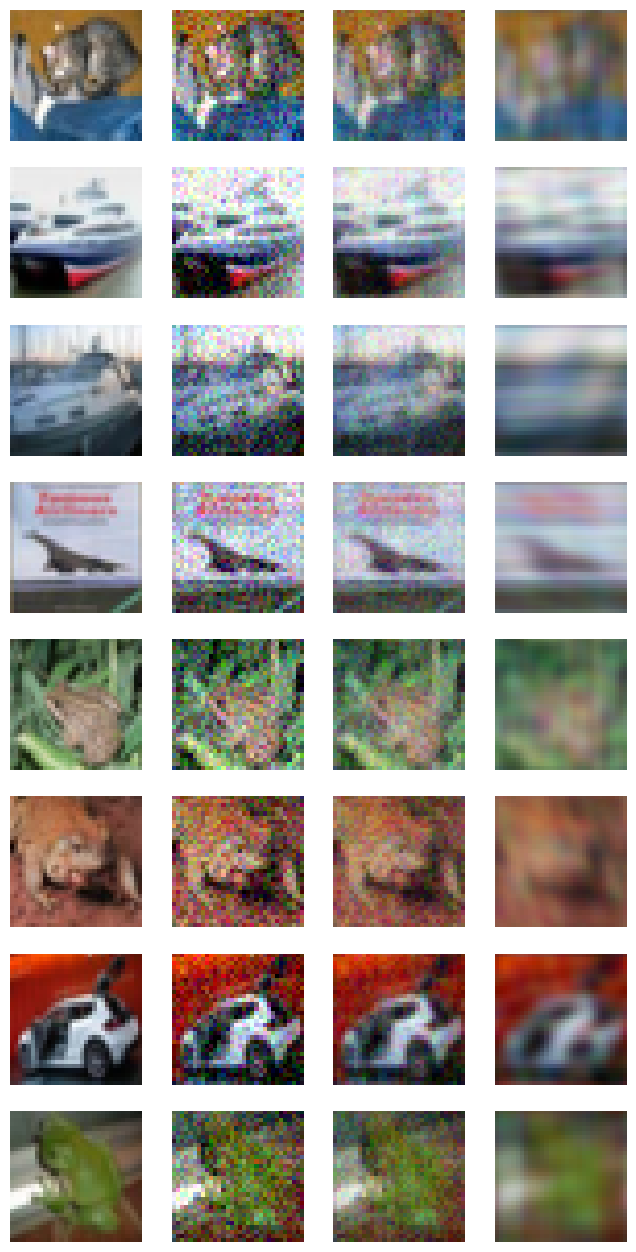

In [5]:
# ============================================================
# FULL PIPELINE (ONE BLOCK)
# 1) Train ResNet-18 (CIFAR-10)
# 2) Save best checkpoint
# 3) AdaptThr nonlinear threshold search
# 4) Final comparison (baseline / classical / AdaptThr)
# 5) Visualization
# ============================================================

import os, io, math, time, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 30
BATCH_SIZE = 128
LR = 0.1

CKPT_PATH = "/kaggle/working/best_model.pth"

# nonlinear search
ALPHAS = [0.9, 1.0, 1.1]
GAMMAS = [1.4, 1.5, 1.6, 1.7]
HF_RATIOS = [0.55, 0.6, 0.65]

# ------------------------------------------------------------
# SEED
# ------------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

transform_test = T.ToTensor()

trainset = torchvision.datasets.CIFAR10(root="/kaggle/working", train=True, download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root="/kaggle/working", train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader  = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------
def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(DEVICE)

model = build_model()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------
def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

best_acc = 0

print("\nTraining start...\n")

for epoch in range(EPOCHS):
    model.train()
    for x, y in trainloader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    scheduler.step()
    acc = evaluate(model)

    print(f"Epoch {epoch+1}/{EPOCHS} | Test Acc: {acc:.2f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), CKPT_PATH)

print(f"\nBest accuracy: {best_acc:.2f}")

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------
model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

# ------------------------------------------------------------
# NORMALIZE
# ------------------------------------------------------------
MEAN = torch.tensor([0.4914,0.4822,0.4465]).view(1,3,1,1).to(DEVICE)
STD  = torch.tensor([0.2470,0.2435,0.2616]).view(1,3,1,1).to(DEVICE)

def normalize(x):
    return (x - MEAN) / STD

# ------------------------------------------------------------
# NOISE
# ------------------------------------------------------------
def add_noise(x, t, s):
    if t=="clean": return x
    if t=="gaussian": return torch.clamp(x + torch.randn_like(x)*s,0,1)
    if t=="salt": 
        mask = torch.rand_like(x)
        x[mask<s] = 0
        x[mask>1-s] = 1
        return x
    return x

# ------------------------------------------------------------
# ADAPTTHR
# ------------------------------------------------------------
def adaptthr(x, alpha, gamma, hf_ratio):
    X = torch.fft.fft2(x)
    X = torch.fft.fftshift(X)

    mag = torch.abs(X)
    phase = torch.angle(X)

    sigma = mag.mean(dim=(-2,-1), keepdim=True)
    tau = alpha * (sigma**gamma)

    mag = torch.clamp(mag - tau, min=0)
    X = mag * torch.exp(1j*phase)

    X = torch.fft.ifftshift(X)
    x = torch.fft.ifft2(X).real
    return torch.clamp(x,0,1)

# ------------------------------------------------------------
# SEARCH
# ------------------------------------------------------------
print("\nSearching best nonlinear threshold...\n")

results = []

for a,g,h in itertools.product(ALPHAS, GAMMAS, HF_RATIOS):
    correct,total = 0,0
    for x,y in testloader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        x = adaptthr(x,a,g,h)
        out = model(normalize(x))
        pred = out.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)

    acc = 100*correct/total
    print(f"alpha={a}, gamma={g}, hf={h} -> {acc:.2f}")
    results.append((a,g,h,acc))

best = sorted(results, key=lambda x:x[3], reverse=True)[0]
print("\nBEST:", best)

# ------------------------------------------------------------
# FINAL COMPARE
# ------------------------------------------------------------
print("\nFinal comparison\n")

methods = ["baseline","adaptthr"]

for t,s in [("clean",0),("gaussian",0.1),("salt",0.05)]:
    print(f"\n{t}-{s}")
    for m in methods:
        correct,total=0,0
        for x,y in testloader:
            x,y = x.to(DEVICE), y.to(DEVICE)

            x = add_noise(x,t,s)

            if m=="adaptthr":
                x = adaptthr(x,best[0],best[1],best[2])

            out = model(normalize(x))
            pred = out.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)

        print(m, 100*correct/total)

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------
print("\nSaving visualization...\n")

x,_ = next(iter(testloader))
x = x[:8].to(DEVICE)

noisy = add_noise(x,"gaussian",0.1)
lin = adaptthr(noisy,0.5,1.0,0.6)
nonlin = adaptthr(noisy,best[0],best[1],best[2])

fig,axs = plt.subplots(8,4,figsize=(8,16))

for i in range(8):
    axs[i,0].imshow(x[i].cpu().permute(1,2,0))
    axs[i,1].imshow(noisy[i].cpu().permute(1,2,0))
    axs[i,2].imshow(lin[i].cpu().permute(1,2,0))
    axs[i,3].imshow(nonlin[i].cpu().permute(1,2,0))

    for j in range(4):
        axs[i,j].axis("off")

plt.savefig("/kaggle/working/result.png")
print("Saved: /kaggle/working/result.png")

In [7]:
# ============================================================
# FULL PIPELINE (FIXED VERSION: NO NORMALIZATION MISMATCH)
# 1) Train ResNet-18 on CIFAR-10 using raw [0,1] inputs
# 2) Save best checkpoint
# 3) Fine search for nonlinear AdaptThr
# 4) Final comparison
# 5) Visualization
# ============================================================

import os
import io
import time
import math
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 30
BATCH_SIZE = 128
NUM_WORKERS = 2
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

CKPT_PATH = "/kaggle/working/best_model_raw_input.pth"
TRAIN_LOG_CSV = "/kaggle/working/train_log_raw_input.csv"
FINE_SEARCH_CSV = "/kaggle/working/fine_search_nonlinear_adaptthr_raw_input.csv"
FINAL_COMPARE_CSV = "/kaggle/working/final_compare_methods_raw_input.csv"
VIZ_DIR = "/kaggle/working/adaptthr_visualizations_raw_input"
os.makedirs(VIZ_DIR, exist_ok=True)

# Linear AdaptThr reference
LINEAR_ALPHA = 0.5
LINEAR_GAMMA = 1.0
LINEAR_HF_RATIO = 0.6
LINEAR_CHANNEL_WISE = False

# Fine search space
FINE_ALPHAS = [0.9, 1.0, 1.1]
FINE_GAMMAS = [1.4, 1.5, 1.6, 1.7, 1.8]
FINE_HF_RATIOS = [0.55, 0.60, 0.65]
FINE_CHANNEL_WISES = [False, True]

LAMBDA_CLEAN_DROP = 2.0

NOISE_SETTINGS = [
    ("clean", 0.0),
    ("gaussian", 0.02),
    ("gaussian", 0.05),
    ("gaussian", 0.10),
    ("speckle", 0.05),
    ("speckle", 0.10),
    ("salt_pepper", 0.02),
    ("salt_pepper", 0.05),
    ("poisson", 1),
    ("poisson", 2),
]

VIZ_CONDITIONS = [
    ("clean", 0.0),
    ("gaussian", 0.10),
    ("salt_pepper", 0.05),
    ("poisson", 1),
]

VIZ_SAMPLES_PER_CONDITION = 8

# ------------------------------------------------------------
# SEED
# ------------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
torch.backends.cudnn.benchmark = True

# ------------------------------------------------------------
# DATA
# NOTE: RAW [0,1] INPUTS ONLY. NO NORMALIZATION ANYWHERE.
# ------------------------------------------------------------
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

transform_test = T.Compose([
    T.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root="/kaggle/working",
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root="/kaggle/working",
    train=False,
    download=True,
    transform=transform_test
)

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train size: {len(trainset)}")
print(f"Test size : {len(testset)}")
print(f"Device    : {DEVICE}")

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------
def build_model(num_classes=10):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

model = build_model(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ------------------------------------------------------------
# BASIC UTILS
# ------------------------------------------------------------
def clamp01(x):
    return torch.clamp(x, 0.0, 1.0)

def to_numpy_img(x):
    x = clamp01(x.detach().cpu())
    return x.permute(1, 2, 0).numpy()

@torch.no_grad()
def evaluate_clean(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        out = model(x)   # RAW INPUT
        pred = out.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / total

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------
print("\nTraining start...\n")

train_log_rows = []
best_acc = -1.0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0
    start_time = time.time()

    for x, y in trainloader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        out = model(x)   # RAW INPUT
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * y.size(0)
        epoch_correct += (out.argmax(dim=1) == y).sum().item()
        epoch_total += y.size(0)

    scheduler.step()

    train_loss = epoch_loss / epoch_total
    train_acc = 100.0 * epoch_correct / epoch_total
    test_acc = evaluate_clean(model, testloader)
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")

    train_log_rows.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "epoch_time_sec": epoch_time,
    })

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), CKPT_PATH)

pd.DataFrame(train_log_rows).to_csv(TRAIN_LOG_CSV, index=False)

print(f"\nBest accuracy: {best_acc:.2f}")
print(f"Saved checkpoint: {CKPT_PATH}")
print(f"Saved train log : {TRAIN_LOG_CSV}")

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------
model = build_model(num_classes=10)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ------------------------------------------------------------
# NOISE
# ------------------------------------------------------------
def add_gaussian_noise(x, severity):
    return clamp01(x + torch.randn_like(x) * severity)

def add_speckle_noise(x, severity):
    return clamp01(x + x * torch.randn_like(x) * severity)

def add_salt_pepper_noise(x, severity):
    out = x.clone()
    B, C, H, W = out.shape
    rand = torch.rand(B, 1, H, W, device=out.device)

    salt_mask = rand < (severity / 2.0)
    pepper_mask = (rand >= (severity / 2.0)) & (rand < severity)

    out = torch.where(salt_mask.expand_as(out), torch.ones_like(out), out)
    out = torch.where(pepper_mask.expand_as(out), torch.zeros_like(out), out)
    return out

def add_poisson_noise(x, severity):
    vals = 32 if severity == 1 else 64
    return clamp01(torch.poisson(x * vals) / vals)

def apply_noise(x, noise_type, severity):
    if noise_type == "clean":
        return x
    elif noise_type == "gaussian":
        return add_gaussian_noise(x, severity)
    elif noise_type == "speckle":
        return add_speckle_noise(x, severity)
    elif noise_type == "salt_pepper":
        return add_salt_pepper_noise(x, severity)
    elif noise_type == "poisson":
        return add_poisson_noise(x, severity)
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")

# ------------------------------------------------------------
# CLASSICAL PREPROCESSING
# ------------------------------------------------------------
def gaussian_blur_torch(x, kernel_size=3, sigma=1.0):
    channels = x.shape[1]
    coords = torch.arange(kernel_size, dtype=torch.float32, device=x.device) - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel2d = torch.outer(g, g).view(1, 1, kernel_size, kernel_size)
    kernel2d = kernel2d.repeat(channels, 1, 1, 1)
    return F.conv2d(x, kernel2d, padding=kernel_size // 2, groups=channels)

def median_filter_torch(x, kernel_size=3):
    pad = kernel_size // 2
    xpad = F.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = xpad.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    patches = patches.contiguous().view(*patches.shape[:4], -1)
    med = patches.median(dim=-1).values
    return med

def bilateral_approx_torch(x, sigma_spatial=1.0, sigma_range=0.1, kernel_size=3):
    B, C, H, W = x.shape
    pad = kernel_size // 2
    xpad = F.pad(x, (pad, pad, pad, pad), mode="reflect")

    coords = torch.arange(kernel_size, device=x.device).float() - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma_spatial ** 2))
    spatial = torch.outer(g, g)
    spatial = spatial / spatial.sum()
    spatial = spatial.view(1, 1, 1, 1, kernel_size, kernel_size)

    patches = xpad.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    center = x.unsqueeze(-1).unsqueeze(-1)
    range_w = torch.exp(-((patches - center) ** 2) / (2 * sigma_range ** 2))
    weights = spatial * range_w
    weights = weights / (weights.sum(dim=(-1, -2), keepdim=True) + 1e-8)
    out = (weights * patches).sum(dim=(-1, -2))
    return out

# ------------------------------------------------------------
# ADAPTTHR
# ------------------------------------------------------------
def radial_mask(H, W, hf_ratio, device):
    yy, xx = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing="ij"
    )
    cy, cx = H // 2, W // 2
    rr = torch.sqrt((yy - cy).float() ** 2 + (xx - cx).float() ** 2)
    rmax = rr.max()
    return (rr >= hf_ratio * rmax).float()

def estimate_sigma_mad(mag, hf_ratio=0.6, channel_wise=False):
    B, C, H, W = mag.shape
    mask = radial_mask(H, W, hf_ratio, mag.device).view(1, 1, H, W)
    vals = mag * mask
    masked_idx = mask.view(-1) > 0
    vals_flat = vals.view(B, C, -1)[:, :, masked_idx]

    median = vals_flat.median(dim=-1, keepdim=True).values
    mad = (vals_flat - median).abs().median(dim=-1).values
    sigma_hat = mad / 0.6745

    if channel_wise:
        return sigma_hat.view(B, C, 1, 1)
    else:
        sigma_hat = sigma_hat.mean(dim=1, keepdim=True)
        return sigma_hat.view(B, 1, 1, 1)

def adaptthr_variant(x, alpha=1.0, gamma=1.0, hf_ratio=0.6, channel_wise=False):
    X = torch.fft.fft2(x, dim=(-2, -1))
    X = torch.fft.fftshift(X, dim=(-2, -1))

    mag = torch.abs(X)
    phase = torch.angle(X)

    sigma_hat = estimate_sigma_mad(mag, hf_ratio=hf_ratio, channel_wise=channel_wise)
    tau = alpha * torch.pow(torch.clamp(sigma_hat, min=1e-8), gamma)

    mag_thr = torch.clamp(mag - tau, min=0.0)
    X_thr = mag_thr * torch.exp(1j * phase)

    X_thr = torch.fft.ifftshift(X_thr, dim=(-2, -1))
    x_rec = torch.fft.ifft2(X_thr, dim=(-2, -1)).real
    return clamp01(x_rec)

def preprocess_batch(x, method_name, nonlinear_cfg=None):
    if method_name == "baseline":
        return x
    elif method_name == "gaussian_blur":
        return clamp01(gaussian_blur_torch(x, kernel_size=3, sigma=1.0))
    elif method_name == "median":
        return clamp01(median_filter_torch(x, kernel_size=3))
    elif method_name == "bilateral":
        return clamp01(bilateral_approx_torch(x, sigma_spatial=1.0, sigma_range=0.1, kernel_size=3))
    elif method_name == "adaptthr_linear":
        return clamp01(adaptthr_variant(
            x,
            alpha=LINEAR_ALPHA,
            gamma=LINEAR_GAMMA,
            hf_ratio=LINEAR_HF_RATIO,
            channel_wise=LINEAR_CHANNEL_WISE
        ))
    elif method_name == "adaptthr_nonlinear":
        assert nonlinear_cfg is not None
        return clamp01(adaptthr_variant(
            x,
            alpha=nonlinear_cfg["alpha"],
            gamma=nonlinear_cfg["gamma"],
            hf_ratio=nonlinear_cfg["hf_ratio"],
            channel_wise=nonlinear_cfg["channel_wise"]
        ))
    else:
        raise ValueError(f"Unknown method: {method_name}")

# ------------------------------------------------------------
# EVALUATION HELPERS
# ------------------------------------------------------------
@torch.no_grad()
def evaluate_method_condition(model, loader, method_name, noise_type, severity, nonlinear_cfg=None):
    model.eval()
    correct = 0
    total = 0
    start = time.time()

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        noisy = apply_noise(x, noise_type, severity)
        proc = preprocess_batch(noisy, method_name, nonlinear_cfg=nonlinear_cfg)

        out = model(proc)   # RAW INPUT, NO NORMALIZE
        pred = out.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    acc = 100.0 * correct / total
    latency_ms = (time.time() - start) / total * 1000.0
    return acc, latency_ms

# ------------------------------------------------------------
# 1) FINE SEARCH
# ------------------------------------------------------------
print("\n" + "="*100)
print("1) Fine search for nonlinear AdaptThr")
print("="*100)

baseline_clean_acc, _ = evaluate_method_condition(model, testloader, "baseline", "clean", 0.0)

fine_rows = []
search_space = list(itertools.product(FINE_ALPHAS, FINE_GAMMAS, FINE_HF_RATIOS, FINE_CHANNEL_WISES))

for idx, (alpha, gamma, hf_ratio, channel_wise) in enumerate(search_space, 1):
    cfg = {
        "alpha": alpha,
        "gamma": gamma,
        "hf_ratio": hf_ratio,
        "channel_wise": channel_wise,
    }
    print(f"\n[{idx}/{len(search_space)}] alpha={alpha}, gamma={gamma}, hf_ratio={hf_ratio}, channel_wise={channel_wise}")

    cond_accs = {}
    for noise_type, severity in NOISE_SETTINGS:
        acc, _ = evaluate_method_condition(
            model, testloader, "adaptthr_nonlinear",
            noise_type, severity, nonlinear_cfg=cfg
        )
        cond_accs[(noise_type, severity)] = acc
        print(f"  {noise_type:12s} severity={str(severity):6s} | acc={acc:.2f}")

    clean_acc = cond_accs[("clean", 0.0)]
    mean_noisy_acc = np.mean([v for (k, v) in cond_accs.items() if k[0] != "clean"])
    clean_drop = baseline_clean_acc - clean_acc
    overall_score = mean_noisy_acc - LAMBDA_CLEAN_DROP * max(clean_drop, 0.0)

    row = {
        "alpha": alpha,
        "gamma": gamma,
        "hf_ratio": hf_ratio,
        "channel_wise": channel_wise,
        "clean_acc": clean_acc,
        "mean_noisy_acc": mean_noisy_acc,
        "clean_drop_vs_baseline": clean_drop,
        "overall_score": overall_score,
    }
    for (noise_type, severity), acc in cond_accs.items():
        row[f"{noise_type}_{severity}"] = acc

    fine_rows.append(row)

fine_df = pd.DataFrame(fine_rows)
fine_df.to_csv(FINE_SEARCH_CSV, index=False)
print(f"\nSaved fine search to: {FINE_SEARCH_CSV}")

print("\nTop 10 by overall_score")
print(
    fine_df.sort_values("overall_score", ascending=False)[[
        "alpha", "gamma", "hf_ratio", "channel_wise",
        "clean_acc", "mean_noisy_acc", "clean_drop_vs_baseline", "overall_score"
    ]].head(10).to_string(index=False)
)

best_row = fine_df.sort_values("overall_score", ascending=False).iloc[0].to_dict()
best_cfg = {
    "alpha": float(best_row["alpha"]),
    "gamma": float(best_row["gamma"]),
    "hf_ratio": float(best_row["hf_ratio"]),
    "channel_wise": bool(best_row["channel_wise"]),
}

print("\nBest nonlinear config:")
print(best_cfg)

# ------------------------------------------------------------
# 2) FINAL COMPARISON
# ------------------------------------------------------------
print("\n" + "="*100)
print("2) Final comparison")
print("="*100)

METHODS = [
    "baseline",
    "bilateral",
    "median",
    "adaptthr_linear",
    "adaptthr_nonlinear",
]

compare_rows = []

for noise_type, severity in NOISE_SETTINGS:
    print(f"\n=== {noise_type} / {severity} ===")
    for method in METHODS:
        acc, latency_ms = evaluate_method_condition(
            model, testloader, method, noise_type, severity, nonlinear_cfg=best_cfg
        )
        compare_rows.append({
            "noise": noise_type,
            "severity": severity,
            "method": method,
            "acc": acc,
            "latency_ms_per_img": latency_ms,
        })
        print(f"{method:18s} | acc={acc:6.2f} | latency={latency_ms:7.3f} ms/img")

compare_df = pd.DataFrame(compare_rows)
compare_df.to_csv(FINAL_COMPARE_CSV, index=False)
print(f"\nSaved final comparison to: {FINAL_COMPARE_CSV}")

print("\nSummary table (accuracy)")
pivot_acc = compare_df.pivot_table(index=["noise", "severity"], columns="method", values="acc")
print(pivot_acc.to_string())

print("\nMean noisy accuracy")
for method in METHODS:
    vals = compare_df[(compare_df["method"] == method) & (compare_df["noise"] != "clean")]["acc"].values
    print(f"{method:18s} | mean_noisy_acc = {vals.mean():.2f}")

print("\nClean accuracy")
for method in METHODS:
    val = compare_df[(compare_df["method"] == method) & (compare_df["noise"] == "clean")]["acc"].values[0]
    print(f"{method:18s} | clean_acc = {val:.2f}")

# ------------------------------------------------------------
# 3) VISUALIZATION
# ------------------------------------------------------------
print("\n" + "="*100)
print("3) Saving visualization images")
print("="*100)

@torch.no_grad()
def predict_label(model, x_single):
    logits = model(x_single.unsqueeze(0).to(DEVICE))   # RAW INPUT, NO NORMALIZE
    pred = logits.argmax(dim=1).item()
    return pred

sample_images = []
sample_labels = []
for i in range(VIZ_SAMPLES_PER_CONDITION):
    img, lab = testset[i]
    sample_images.append(img)
    sample_labels.append(lab)

sample_images = torch.stack(sample_images, dim=0).to(DEVICE)
sample_labels = torch.tensor(sample_labels, device=DEVICE)
class_names = testset.classes

for noise_type, severity in VIZ_CONDITIONS:
    noisy = apply_noise(sample_images, noise_type, severity)
    linear = preprocess_batch(noisy, "adaptthr_linear")
    nonlinear = preprocess_batch(noisy, "adaptthr_nonlinear", nonlinear_cfg=best_cfg)
    bilateral = preprocess_batch(noisy, "bilateral")
    median = preprocess_batch(noisy, "median")

    fig, axes = plt.subplots(VIZ_SAMPLES_PER_CONDITION, 6, figsize=(16, 2.4 * VIZ_SAMPLES_PER_CONDITION))
    if VIZ_SAMPLES_PER_CONDITION == 1:
        axes = np.expand_dims(axes, 0)

    col_titles = ["clean", "noisy", "linear", "nonlinear", "bilateral", "median"]
    for j, t in enumerate(col_titles):
        axes[0, j].set_title(t)

    for i in range(VIZ_SAMPLES_PER_CONDITION):
        imgs = [
            sample_images[i],
            noisy[i],
            linear[i],
            nonlinear[i],
            bilateral[i],
            median[i]
        ]

        for j, im in enumerate(imgs):
            axes[i, j].imshow(to_numpy_img(im))
            axes[i, j].axis("off")

        gt = class_names[sample_labels[i].item()]
        pred_noisy = class_names[predict_label(model, noisy[i])]
        pred_linear = class_names[predict_label(model, linear[i])]
        pred_nonlinear = class_names[predict_label(model, nonlinear[i])]

        axes[i, 0].set_ylabel(
            f"GT:{gt}\nN:{pred_noisy}\nL:{pred_linear}\nNL:{pred_nonlinear}",
            fontsize=8
        )

    plt.tight_layout()
    out_path = os.path.join(VIZ_DIR, f"viz_{noise_type}_{str(severity).replace('.', '_')}.png")
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# ------------------------------------------------------------
# FINAL CONCISE REPORT
# ------------------------------------------------------------
print("\n" + "="*100)
print("Final concise report")
print("="*100)

def get_metric(df, method, noise, severity):
    return df[
        (df["method"] == method) &
        (df["noise"] == noise) &
        (df["severity"] == severity)
    ]["acc"].values[0]

for noise_type, severity in NOISE_SETTINGS:
    vals = []
    for method in METHODS:
        vals.append((method, get_metric(compare_df, method, noise_type, severity)))
    best_method, best_acc = sorted(vals, key=lambda x: x[1], reverse=True)[0]
    print(f"{noise_type:12s} | severity={str(severity):6s} | best={best_method:18s} | acc={best_acc:.2f}")

print("\nOutput files:")
print(CKPT_PATH)
print(TRAIN_LOG_CSV)
print(FINE_SEARCH_CSV)
print(FINAL_COMPARE_CSV)
print(VIZ_DIR)

Train size: 50000
Test size : 10000
Device    : cuda

Training start...

Epoch 1/30 | Train Loss: 2.2133 | Train Acc: 27.97 | Test Acc: 39.66
Epoch 2/30 | Train Loss: 1.5589 | Train Acc: 42.63 | Test Acc: 43.63
Epoch 3/30 | Train Loss: 1.3997 | Train Acc: 49.25 | Test Acc: 51.92
Epoch 4/30 | Train Loss: 1.2624 | Train Acc: 54.78 | Test Acc: 56.30
Epoch 5/30 | Train Loss: 1.1309 | Train Acc: 59.63 | Test Acc: 53.99
Epoch 6/30 | Train Loss: 1.0409 | Train Acc: 63.25 | Test Acc: 65.39
Epoch 7/30 | Train Loss: 0.9667 | Train Acc: 65.95 | Test Acc: 66.65
Epoch 8/30 | Train Loss: 0.9124 | Train Acc: 68.15 | Test Acc: 60.99
Epoch 9/30 | Train Loss: 0.8714 | Train Acc: 69.60 | Test Acc: 68.14
Epoch 10/30 | Train Loss: 0.8285 | Train Acc: 71.34 | Test Acc: 67.47
Epoch 11/30 | Train Loss: 0.7960 | Train Acc: 72.34 | Test Acc: 66.45
Epoch 12/30 | Train Loss: 0.7670 | Train Acc: 73.38 | Test Acc: 55.08
Epoch 13/30 | Train Loss: 0.7351 | Train Acc: 74.48 | Test Acc: 67.74
Epoch 14/30 | Train Loss: 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Data from your final comparison
# =========================================================

methods = [
    "Baseline",
    "Bilateral",
    "Median",
    "AdaptThr\n(Linear)",
    "AdaptThr\n(Nonlinear)",
]

results = {
    "clean": {
        "Baseline": 85.25,
        "Bilateral": 82.79,
        "Median": 71.44,
        "AdaptThr\n(Linear)": 85.06,
        "AdaptThr\n(Nonlinear)": 85.16,
    },
    "gaussian_0.02": {
        "Baseline": 84.85,
        "Bilateral": 82.85,
        "Median": 70.71,
        "AdaptThr\n(Linear)": 84.70,
        "AdaptThr\n(Nonlinear)": 84.78,
    },
    "gaussian_0.05": {
        "Baseline": 81.33,
        "Bilateral": 83.10,
        "Median": 68.62,
        "AdaptThr\n(Linear)": 82.67,
        "AdaptThr\n(Nonlinear)": 82.27,
    },
    "gaussian_0.1": {
        "Baseline": 67.93,
        "Bilateral": 73.91,
        "Median": 63.71,
        "AdaptThr\n(Linear)": 71.25,
        "AdaptThr\n(Nonlinear)": 73.55,
    },
    "speckle_0.05": {
        "Baseline": 84.70,
        "Bilateral": 82.84,
        "Median": 70.54,
        "AdaptThr\n(Linear)": 84.66,
        "AdaptThr\n(Nonlinear)": 84.54,
    },
    "speckle_0.1": {
        "Baseline": 81.79,
        "Bilateral": 82.40,
        "Median": 68.88,
        "AdaptThr\n(Linear)": 81.97,
        "AdaptThr\n(Nonlinear)": 82.31,
    },
    "salt_pepper_0.02": {
        "Baseline": 66.47,
        "Bilateral": 64.95,
        "Median": 71.72,
        "AdaptThr\n(Linear)": 69.50,
        "AdaptThr\n(Nonlinear)": 72.14,
    },
    "salt_pepper_0.05": {
        "Baseline": 39.81,
        "Bilateral": 39.35,
        "Median": 72.25,
        "AdaptThr\n(Linear)": 46.87,
        "AdaptThr\n(Nonlinear)": 56.81,
    },
    "poisson_1": {
        "Baseline": 61.86,
        "Bilateral": 66.85,
        "Median": 62.83,
        "AdaptThr\n(Linear)": 65.67,
        "AdaptThr\n(Nonlinear)": 68.87,
    },
    "poisson_2": {
        "Baseline": 73.38,
        "Bilateral": 78.05,
        "Median": 66.11,
        "AdaptThr\n(Linear)": 75.85,
        "AdaptThr\n(Nonlinear)": 76.67,
    },
}

mean_noisy = {
    "Baseline": 71.35,
    "Bilateral": 72.70,
    "Median": 68.37,
    "AdaptThr\n(Linear)": 73.68,
    "AdaptThr\n(Nonlinear)": 75.77,
}

clean_acc = {
    "Baseline": 85.25,
    "Bilateral": 82.79,
    "Median": 71.44,
    "AdaptThr\n(Linear)": 85.06,
    "AdaptThr\n(Nonlinear)": 85.16,
}

# =========================================================
# Figure 1: Representative conditions
# =========================================================
def make_fig1():
    representative = ["clean", "gaussian_0.1", "salt_pepper_0.05", "poisson_1"]
    display_names = ["Clean", "Gaussian\n(0.1)", "Salt&Pepper\n(0.05)", "Poisson\n(1)"]

    x = np.arange(len(representative))
    width = 0.16

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, m in enumerate(methods):
        vals = [results[r][m] for r in representative]
        ax.bar(x + (i - 2) * width, vals, width, label=m)

    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(display_names)
    ax.set_ylim(30, 90)
    ax.legend(frameon=False, ncol=2)
    ax.set_title("Comparison under representative noise conditions")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig("fig1.png", dpi=300, bbox_inches="tight")
    plt.close()

# =========================================================
# Figure 2: Heatmap of all conditions
# =========================================================
def make_fig2():
    conds = [
        "clean",
        "gaussian_0.02", "gaussian_0.05", "gaussian_0.1",
        "speckle_0.05", "speckle_0.1",
        "salt_pepper_0.02", "salt_pepper_0.05",
        "poisson_1", "poisson_2",
    ]
    cond_labels = [
        "Clean",
        "Gaussian 0.02", "Gaussian 0.05", "Gaussian 0.1",
        "Speckle 0.05", "Speckle 0.1",
        "S&P 0.02", "S&P 0.05",
        "Poisson 1", "Poisson 2",
    ]

    matrix = np.array([[results[c][m] for m in methods] for c in conds])

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(matrix, aspect="auto")

    ax.set_xticks(np.arange(len(methods)))
    ax.set_xticklabels(methods)
    ax.set_yticks(np.arange(len(cond_labels)))
    ax.set_yticklabels(cond_labels)
    ax.set_title("Accuracy heatmap across all noise conditions")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center", fontsize=8)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Accuracy (%)")

    plt.tight_layout()
    plt.savefig("fig2.png", dpi=300, bbox_inches="tight")
    plt.close()

# =========================================================
# Figure 3: Clean vs Mean Noisy trade-off
# =========================================================
def make_fig3():
    x = [clean_acc[m] for m in methods]
    y = [mean_noisy[m] for m in methods]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, s=100)

    for i, m in enumerate(methods):
        ax.annotate(m.replace("\n", " "), (x[i], y[i]), xytext=(5, 5), textcoords="offset points", fontsize=9)

    ax.set_xlabel("Clean Accuracy (%)")
    ax.set_ylabel("Mean Noisy Accuracy (%)")
    ax.set_title("Clean vs Mean Noisy Trade-off")
    ax.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig("fig3.png", dpi=300, bbox_inches="tight")
    plt.close()

# =========================================================
# Figure 4: Ablation (Baseline vs Linear vs Nonlinear)
# =========================================================
def make_fig4():
    selected_methods = ["Baseline", "AdaptThr\n(Linear)", "AdaptThr\n(Nonlinear)"]
    conds = [
        "clean",
        "gaussian_0.1",
        "salt_pepper_0.02",
        "salt_pepper_0.05",
        "poisson_1",
        "poisson_2",
    ]
    cond_labels = [
        "Clean",
        "Gaussian\n0.1",
        "S&P\n0.02",
        "S&P\n0.05",
        "Poisson\n1",
        "Poisson\n2",
    ]

    x = np.arange(len(conds))
    width = 0.22

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, m in enumerate(selected_methods):
        vals = [results[c][m] for c in conds]
        ax.bar(x + (i - 1) * width, vals, width, label=m)

    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(cond_labels)
    ax.set_ylim(35, 90)
    ax.legend(frameon=False)
    ax.set_title("Ablation: Linear vs Nonlinear thresholding")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig("fig4.png", dpi=300, bbox_inches="tight")
    plt.close()

# =========================================================
# Run all
# =========================================================
if __name__ == "__main__":
    make_fig1()
    make_fig2()
    make_fig3()
    make_fig4()
    print("Saved: fig1.png, fig2.png, fig3.png, fig4.png")
    print("Current directory:", os.getcwd())

Saved: fig1.png, fig2.png, fig3.png, fig4.png
Current directory: /kaggle/working


In [3]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import DataLoader

# =========================================================
# Config
# =========================================================
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_PATH = "best_model_raw_input.pth"
NUM_CLASSES = 10

# training
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

# best nonlinear config
BEST_ALPHA = 1.0
BEST_GAMMA = 1.6
BEST_HF_RATIO = 0.6
BEST_CHANNEL_WISE = True

# linear reference
LINEAR_ALPHA = 0.5
LINEAR_GAMMA = 1.0
LINEAR_HF_RATIO = 0.6
LINEAR_CHANNEL_WISE = False

# figure settings
SAMPLES_PER_ROW = 4
OUT_MAIN = "qualitative_main.png"
OUT_GAUSSIAN = "qualitative_gaussian.png"
OUT_SALT = "qualitative_saltpepper.png"
OUT_POISSON = "qualitative_poisson.png"

# =========================================================
# Seed
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# Model
# =========================================================
def build_model(num_classes=10):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

model = build_model(NUM_CLASSES)

# =========================================================
# Data
# =========================================================
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

transform_test = T.Compose([
    T.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root=".",
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root=".",
    train=False,
    download=True,
    transform=transform_test
)

class_names = testset.classes

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# =========================================================
# Utils
# =========================================================
def clamp01(x):
    return torch.clamp(x, 0.0, 1.0)

def to_numpy_img(x):
    x = clamp01(x.detach().cpu())
    return x.permute(1, 2, 0).numpy()

@torch.no_grad()
def predict_label(x_single):
    logits = model(x_single.unsqueeze(0).to(DEVICE))
    pred = logits.argmax(dim=1).item()
    return class_names[pred]

# =========================================================
# Training / Evaluation
# =========================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100.0 * correct / total
    return acc

def train_model(model, trainloader, testloader, epochs, ckpt_path):
    best_acc = 0.0

    print("Training start...\n")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)

        scheduler.step()

        test_acc = evaluate(model, testloader)
        print(f"Epoch {epoch+1}/{epochs} | Test Acc: {test_acc:.2f}")

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), ckpt_path)

    print(f"\nBest accuracy: {best_acc:.2f}")
    return best_acc

# =========================================================
# Noise
# =========================================================
def add_gaussian_noise(x, severity):
    return clamp01(x + torch.randn_like(x) * severity)

def add_speckle_noise(x, severity):
    return clamp01(x + x * torch.randn_like(x) * severity)

def add_salt_pepper_noise(x, severity):
    out = x.clone()
    B, C, H, W = out.shape
    rand = torch.rand(B, 1, H, W, device=out.device)
    salt_mask = rand < (severity / 2.0)
    pepper_mask = (rand >= (severity / 2.0)) & (rand < severity)
    out = torch.where(salt_mask.expand_as(out), torch.ones_like(out), out)
    out = torch.where(pepper_mask.expand_as(out), torch.zeros_like(out), out)
    return out

def add_poisson_noise(x, severity):
    vals = 32 if severity == 1 else 64
    return clamp01(torch.poisson(x * vals) / vals)

def apply_noise(x, noise_type, severity):
    if noise_type == "clean":
        return x
    elif noise_type == "gaussian":
        return add_gaussian_noise(x, severity)
    elif noise_type == "speckle":
        return add_speckle_noise(x, severity)
    elif noise_type == "salt_pepper":
        return add_salt_pepper_noise(x, severity)
    elif noise_type == "poisson":
        return add_poisson_noise(x, severity)
    else:
        raise ValueError(noise_type)

# =========================================================
# Classical preprocessing
# =========================================================
def median_filter_torch(x, kernel_size=3):
    pad = kernel_size // 2
    xpad = F.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = xpad.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    patches = patches.contiguous().view(*patches.shape[:4], -1)
    return patches.median(dim=-1).values

def bilateral_approx_torch(x, sigma_spatial=1.0, sigma_range=0.1, kernel_size=3):
    B, C, H, W = x.shape
    pad = kernel_size // 2
    xpad = F.pad(x, (pad, pad, pad, pad), mode="reflect")

    coords = torch.arange(kernel_size, device=x.device).float() - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma_spatial ** 2))
    spatial = torch.outer(g, g)
    spatial = spatial / spatial.sum()
    spatial = spatial.view(1, 1, 1, 1, kernel_size, kernel_size)

    patches = xpad.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    center = x.unsqueeze(-1).unsqueeze(-1)
    range_w = torch.exp(-((patches - center) ** 2) / (2 * sigma_range ** 2))
    weights = spatial * range_w
    weights = weights / (weights.sum(dim=(-1, -2), keepdim=True) + 1e-8)
    return (weights * patches).sum(dim=(-1, -2))

# =========================================================
# AdaptThr
# =========================================================
def radial_mask(H, W, hf_ratio, device):
    yy, xx = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing="ij"
    )
    cy, cx = H // 2, W // 2
    rr = torch.sqrt((yy - cy).float() ** 2 + (xx - cx).float() ** 2)
    rmax = rr.max()
    return (rr >= hf_ratio * rmax).float()

def estimate_sigma_mad(mag, hf_ratio=0.6, channel_wise=False):
    B, C, H, W = mag.shape
    mask = radial_mask(H, W, hf_ratio, mag.device).view(1, 1, H, W)
    vals = mag * mask
    masked_idx = mask.view(-1) > 0
    vals_flat = vals.view(B, C, -1)[:, :, masked_idx]

    median = vals_flat.median(dim=-1, keepdim=True).values
    mad = (vals_flat - median).abs().median(dim=-1).values
    sigma_hat = mad / 0.6745

    if channel_wise:
        return sigma_hat.view(B, C, 1, 1)
    else:
        return sigma_hat.mean(dim=1, keepdim=True).view(B, 1, 1, 1)

def adaptthr_variant(x, alpha=1.0, gamma=1.0, hf_ratio=0.6, channel_wise=False):
    X = torch.fft.fft2(x, dim=(-2, -1))
    X = torch.fft.fftshift(X, dim=(-2, -1))

    mag = torch.abs(X)
    phase = torch.angle(X)

    sigma_hat = estimate_sigma_mad(mag, hf_ratio=hf_ratio, channel_wise=channel_wise)
    tau = alpha * torch.pow(torch.clamp(sigma_hat, min=1e-8), gamma)

    mag_thr = torch.clamp(mag - tau, min=0.0)
    X_thr = mag_thr * torch.exp(1j * phase)

    X_thr = torch.fft.ifftshift(X_thr, dim=(-2, -1))
    x_rec = torch.fft.ifft2(X_thr, dim=(-2, -1)).real
    return clamp01(x_rec)

def preprocess_batch(x, method):
    if method == "clean":
        return x
    elif method == "bilateral":
        return clamp01(
            bilateral_approx_torch(x, sigma_spatial=1.0, sigma_range=0.1, kernel_size=3)
        )
    elif method == "median":
        return clamp01(median_filter_torch(x, kernel_size=3))
    elif method == "linear":
        return clamp01(adaptthr_variant(
            x,
            alpha=LINEAR_ALPHA,
            gamma=LINEAR_GAMMA,
            hf_ratio=LINEAR_HF_RATIO,
            channel_wise=LINEAR_CHANNEL_WISE
        ))
    elif method == "nonlinear":
        return clamp01(adaptthr_variant(
            x,
            alpha=BEST_ALPHA,
            gamma=BEST_GAMMA,
            hf_ratio=BEST_HF_RATIO,
            channel_wise=BEST_CHANNEL_WISE
        ))
    else:
        raise ValueError(method)

# =========================================================
# Sample selection
# =========================================================
def collect_samples(num_samples=4, start_idx=0):
    imgs, labels = [], []
    for i in range(start_idx, start_idx + num_samples):
        img, lab = testset[i]
        imgs.append(img)
        labels.append(lab)
    imgs = torch.stack(imgs, dim=0).to(DEVICE)
    labels = torch.tensor(labels, device=DEVICE)
    return imgs, labels

# =========================================================
# Plot helpers
# =========================================================
def save_condition_grid(noise_type, severity, out_path, start_idx=0):
    clean_imgs, gt_labels = collect_samples(SAMPLES_PER_ROW, start_idx=start_idx)

    noisy = apply_noise(clean_imgs, noise_type, severity)
    bilateral = preprocess_batch(noisy, "bilateral")
    median = preprocess_batch(noisy, "median")
    linear = preprocess_batch(noisy, "linear")
    nonlinear = preprocess_batch(noisy, "nonlinear")

    cols = ["Clean", "Noisy", "Bilateral", "Median", "Linear", "Nonlinear"]
    tensors = [clean_imgs, noisy, bilateral, median, linear, nonlinear]

    fig, axes = plt.subplots(SAMPLES_PER_ROW, len(cols), figsize=(14, 2.6 * SAMPLES_PER_ROW))
    if SAMPLES_PER_ROW == 1:
        axes = np.expand_dims(axes, 0)

    for j, c in enumerate(cols):
        axes[0, j].set_title(c, fontsize=11)

    for i in range(SAMPLES_PER_ROW):
        gt = class_names[gt_labels[i].item()]
        pred_noisy = predict_label(noisy[i])
        pred_linear = predict_label(linear[i])
        pred_nonlinear = predict_label(nonlinear[i])

        for j in range(len(cols)):
            axes[i, j].imshow(to_numpy_img(tensors[j][i]))
            axes[i, j].axis("off")

        axes[i, 0].set_ylabel(
            f"GT: {gt}\nN: {pred_noisy}\nL: {pred_linear}\nNL: {pred_nonlinear}",
            fontsize=8
        )

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

def save_main_figure(out_path):
    row_specs = [
        ("clean", 0.0, 0),
        ("gaussian", 0.1, 4),
        ("salt_pepper", 0.05, 8),
        ("poisson", 1, 12),
    ]

    cols = ["Clean", "Noisy", "Bilateral", "Median", "Linear", "Nonlinear"]
    nrows = len(row_specs)
    fig, axes = plt.subplots(nrows, len(cols), figsize=(14, 2.8 * nrows))

    for j, c in enumerate(cols):
        axes[0, j].set_title(c, fontsize=11)

    for r, (noise_type, severity, start_idx) in enumerate(row_specs):
        clean_imgs, gt_labels = collect_samples(1, start_idx=start_idx)

        noisy = apply_noise(clean_imgs, noise_type, severity)
        bilateral = preprocess_batch(noisy, "bilateral")
        median = preprocess_batch(noisy, "median")
        linear = preprocess_batch(noisy, "linear")
        nonlinear = preprocess_batch(noisy, "nonlinear")

        tensors = [clean_imgs, noisy, bilateral, median, linear, nonlinear]

        gt = class_names[gt_labels[0].item()]
        pred_noisy = predict_label(noisy[0])
        pred_linear = predict_label(linear[0])
        pred_nonlinear = predict_label(nonlinear[0])

        row_name = f"{noise_type}\nsev={severity}\nGT:{gt}\nN:{pred_noisy}\nL:{pred_linear}\nNL:{pred_nonlinear}"
        axes[r, 0].set_ylabel(row_name, fontsize=8)

        for j in range(len(cols)):
            axes[r, j].imshow(to_numpy_img(tensors[j][0]))
            axes[r, j].axis("off")

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# =========================================================
# Main
# =========================================================
if __name__ == "__main__":
    if os.path.exists(CKPT_PATH):
        print(f"Checkpoint found: {CKPT_PATH}")
        state = torch.load(CKPT_PATH, map_location=DEVICE)
        model.load_state_dict(state, strict=True)
        model.eval()
        print("Loaded pretrained weights.\n")
    else:
        print(f"Checkpoint not found: {CKPT_PATH}")
        print("Start training from scratch.\n")
        train_model(model, trainloader, testloader, EPOCHS, CKPT_PATH)

        print("\nLoading best checkpoint...")
        state = torch.load(CKPT_PATH, map_location=DEVICE)
        model.load_state_dict(state, strict=True)
        model.eval()

    final_acc = evaluate(model, testloader)
    print(f"\nFinal loaded model test accuracy: {final_acc:.2f}\n")

    save_main_figure(OUT_MAIN)
    save_condition_grid("gaussian", 0.1, OUT_GAUSSIAN, start_idx=20)
    save_condition_grid("salt_pepper", 0.05, OUT_SALT, start_idx=40)
    save_condition_grid("poisson", 1, OUT_POISSON, start_idx=60)

    print("Done.")

100%|██████████| 170M/170M [00:03<00:00, 48.3MB/s] 


Checkpoint not found: best_model_raw_input.pth
Start training from scratch.

Training start...

Epoch 1/30 | Test Acc: 49.82
Epoch 2/30 | Test Acc: 57.44
Epoch 3/30 | Test Acc: 59.33
Epoch 4/30 | Test Acc: 62.70
Epoch 5/30 | Test Acc: 51.35
Epoch 6/30 | Test Acc: 70.42
Epoch 7/30 | Test Acc: 66.11
Epoch 8/30 | Test Acc: 72.63
Epoch 9/30 | Test Acc: 68.91
Epoch 10/30 | Test Acc: 76.19
Epoch 11/30 | Test Acc: 73.01
Epoch 12/30 | Test Acc: 78.38
Epoch 13/30 | Test Acc: 74.64
Epoch 14/30 | Test Acc: 78.39
Epoch 15/30 | Test Acc: 79.51
Epoch 16/30 | Test Acc: 80.30
Epoch 17/30 | Test Acc: 79.59
Epoch 18/30 | Test Acc: 78.30
Epoch 19/30 | Test Acc: 81.74
Epoch 20/30 | Test Acc: 80.78
Epoch 21/30 | Test Acc: 80.69
Epoch 22/30 | Test Acc: 81.95
Epoch 23/30 | Test Acc: 83.06
Epoch 24/30 | Test Acc: 84.04
Epoch 25/30 | Test Acc: 83.83
Epoch 26/30 | Test Acc: 84.28
Epoch 27/30 | Test Acc: 84.51
Epoch 28/30 | Test Acc: 84.39
Epoch 29/30 | Test Acc: 84.54
Epoch 30/30 | Test Acc: 84.54

Best accurac

In [4]:
import os
import csv
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import DataLoader

# =========================================================
# Config
# =========================================================
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_PATH = "best_model_raw_input.pth"
NUM_CLASSES = 10

# training
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

# best nonlinear config (네 로그 기준)
BEST_ALPHA = 0.9
BEST_GAMMA = 1.4
BEST_HF_RATIO = 0.55
BEST_CHANNEL_WISE = True

# linear reference
LINEAR_ALPHA = 0.5
LINEAR_GAMMA = 1.0
LINEAR_HF_RATIO = 0.6
LINEAR_CHANNEL_WISE = False

# figure settings
SAMPLES_PER_ROW = 4
OUT_MAIN = "qualitative_main.png"
OUT_GAUSSIAN = "qualitative_gaussian.png"
OUT_SALT = "qualitative_saltpepper.png"
OUT_POISSON = "qualitative_poisson.png"

# quantitative output
CSV_PATH = "quantitative_results.csv"

# evaluation conditions
EVAL_CONDITIONS = [
    ("clean", 0.0),
    ("gaussian", 0.1),
    ("salt_pepper", 0.05),
    ("poisson", 1),
]

# =========================================================
# Seed
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# Model
# =========================================================
def build_model(num_classes=10):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

model = build_model(NUM_CLASSES)

# =========================================================
# Data
# =========================================================
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

transform_test = T.Compose([
    T.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root=".",
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root=".",
    train=False,
    download=True,
    transform=transform_test
)

class_names = testset.classes

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# =========================================================
# Utils
# =========================================================
def clamp01(x):
    return torch.clamp(x, 0.0, 1.0)

def to_numpy_img(x):
    x = clamp01(x.detach().cpu())
    return x.permute(1, 2, 0).numpy()

@torch.no_grad()
def predict_label(x_single):
    logits = model(x_single.unsqueeze(0).to(DEVICE))
    pred = logits.argmax(dim=1).item()
    return class_names[pred]

# =========================================================
# Training / Evaluation
# =========================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

@torch.no_grad()
def evaluate_clean_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100.0 * correct / total
    return acc

def train_model(model, trainloader, testloader, epochs, ckpt_path):
    best_acc = 0.0

    print("Training start...\n")

    for epoch in range(epochs):
        model.train()

        for images, labels in trainloader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        scheduler.step()

        test_acc = evaluate_clean_accuracy(model, testloader)
        print(f"Epoch {epoch+1}/{epochs} | Test Acc: {test_acc:.2f}")

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), ckpt_path)

    print(f"\nBest accuracy: {best_acc:.2f}")
    return best_acc

# =========================================================
# Noise
# =========================================================
def add_gaussian_noise(x, severity):
    return clamp01(x + torch.randn_like(x) * severity)

def add_speckle_noise(x, severity):
    return clamp01(x + x * torch.randn_like(x) * severity)

def add_salt_pepper_noise(x, severity):
    out = x.clone()
    B, C, H, W = out.shape
    rand = torch.rand(B, 1, H, W, device=out.device)
    salt_mask = rand < (severity / 2.0)
    pepper_mask = (rand >= (severity / 2.0)) & (rand < severity)
    out = torch.where(salt_mask.expand_as(out), torch.ones_like(out), out)
    out = torch.where(pepper_mask.expand_as(out), torch.zeros_like(out), out)
    return out

def add_poisson_noise(x, severity):
    vals = 32 if severity == 1 else 64
    return clamp01(torch.poisson(x * vals) / vals)

def apply_noise(x, noise_type, severity):
    if noise_type == "clean":
        return x
    elif noise_type == "gaussian":
        return add_gaussian_noise(x, severity)
    elif noise_type == "speckle":
        return add_speckle_noise(x, severity)
    elif noise_type == "salt_pepper":
        return add_salt_pepper_noise(x, severity)
    elif noise_type == "poisson":
        return add_poisson_noise(x, severity)
    else:
        raise ValueError(noise_type)

# =========================================================
# Classical preprocessing
# =========================================================
def median_filter_torch(x, kernel_size=3):
    pad = kernel_size // 2
    xpad = F.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = xpad.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    patches = patches.contiguous().view(*patches.shape[:4], -1)
    return patches.median(dim=-1).values

def bilateral_approx_torch(x, sigma_spatial=1.0, sigma_range=0.1, kernel_size=3):
    B, C, H, W = x.shape
    pad = kernel_size // 2
    xpad = F.pad(x, (pad, pad, pad, pad), mode="reflect")

    coords = torch.arange(kernel_size, device=x.device).float() - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma_spatial ** 2))
    spatial = torch.outer(g, g)
    spatial = spatial / spatial.sum()
    spatial = spatial.view(1, 1, 1, 1, kernel_size, kernel_size)

    patches = xpad.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    center = x.unsqueeze(-1).unsqueeze(-1)
    range_w = torch.exp(-((patches - center) ** 2) / (2 * sigma_range ** 2))
    weights = spatial * range_w
    weights = weights / (weights.sum(dim=(-1, -2), keepdim=True) + 1e-8)
    return (weights * patches).sum(dim=(-1, -2))

# =========================================================
# AdaptThr
# =========================================================
def radial_mask(H, W, hf_ratio, device):
    yy, xx = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing="ij"
    )
    cy, cx = H // 2, W // 2
    rr = torch.sqrt((yy - cy).float() ** 2 + (xx - cx).float() ** 2)
    rmax = rr.max()
    return (rr >= hf_ratio * rmax).float()

def estimate_sigma_mad(mag, hf_ratio=0.6, channel_wise=False):
    B, C, H, W = mag.shape
    mask = radial_mask(H, W, hf_ratio, mag.device).view(1, 1, H, W)
    vals = mag * mask
    masked_idx = mask.view(-1) > 0
    vals_flat = vals.view(B, C, -1)[:, :, masked_idx]

    median = vals_flat.median(dim=-1, keepdim=True).values
    mad = (vals_flat - median).abs().median(dim=-1).values
    sigma_hat = mad / 0.6745

    if channel_wise:
        return sigma_hat.view(B, C, 1, 1)
    else:
        return sigma_hat.mean(dim=1, keepdim=True).view(B, 1, 1, 1)

def adaptthr_variant(x, alpha=1.0, gamma=1.0, hf_ratio=0.6, channel_wise=False):
    X = torch.fft.fft2(x, dim=(-2, -1))
    X = torch.fft.fftshift(X, dim=(-2, -1))

    mag = torch.abs(X)
    phase = torch.angle(X)

    sigma_hat = estimate_sigma_mad(mag, hf_ratio=hf_ratio, channel_wise=channel_wise)
    tau = alpha * torch.pow(torch.clamp(sigma_hat, min=1e-8), gamma)

    mag_thr = torch.clamp(mag - tau, min=0.0)
    X_thr = mag_thr * torch.exp(1j * phase)

    X_thr = torch.fft.ifftshift(X_thr, dim=(-2, -1))
    x_rec = torch.fft.ifft2(X_thr, dim=(-2, -1)).real
    return clamp01(x_rec)

def preprocess_batch(x, method):
    if method == "baseline":
        return x
    elif method == "bilateral":
        return clamp01(
            bilateral_approx_torch(x, sigma_spatial=1.0, sigma_range=0.1, kernel_size=3)
        )
    elif method == "median":
        return clamp01(median_filter_torch(x, kernel_size=3))
    elif method == "linear":
        return clamp01(adaptthr_variant(
            x,
            alpha=LINEAR_ALPHA,
            gamma=LINEAR_GAMMA,
            hf_ratio=LINEAR_HF_RATIO,
            channel_wise=LINEAR_CHANNEL_WISE
        ))
    elif method == "nonlinear":
        return clamp01(adaptthr_variant(
            x,
            alpha=BEST_ALPHA,
            gamma=BEST_GAMMA,
            hf_ratio=BEST_HF_RATIO,
            channel_wise=BEST_CHANNEL_WISE
        ))
    else:
        raise ValueError(method)

# =========================================================
# Quantitative evaluation
# =========================================================
@torch.no_grad()
def evaluate_with_preprocessing(model, loader, noise_type, severity, method):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        noisy = apply_noise(images, noise_type, severity)
        processed = preprocess_batch(noisy, method)

        logits = model(processed)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / total

def run_quantitative_comparison(model, loader):
    methods = ["baseline", "bilateral", "median", "linear", "nonlinear"]
    results = []

    print("\nFinal comparison\n")

    for noise_type, severity in EVAL_CONDITIONS:
        row = {
            "condition": f"{noise_type}-{severity}"
        }
        print(f"{noise_type}-{severity}")

        for method in methods:
            acc = evaluate_with_preprocessing(model, loader, noise_type, severity, method)
            row[method] = acc
            print(f"{method:<10} {acc:.2f}")

        print()
        results.append(row)

    return results

def save_results_csv(results, csv_path):
    fieldnames = ["condition", "baseline", "bilateral", "median", "linear", "nonlinear"]
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)
    print(f"Saved CSV: {csv_path}")

def print_markdown_table(results):
    print("\nMarkdown Table\n")
    print("| Condition | Baseline | Bilateral | Median | Linear | Nonlinear |")
    print("|---|---:|---:|---:|---:|---:|")
    for row in results:
        print(
            f"| {row['condition']} | "
            f"{row['baseline']:.2f} | "
            f"{row['bilateral']:.2f} | "
            f"{row['median']:.2f} | "
            f"{row['linear']:.2f} | "
            f"{row['nonlinear']:.2f} |"
        )

# =========================================================
# Sample selection
# =========================================================
def collect_samples(num_samples=4, start_idx=0):
    imgs, labels = [], []
    for i in range(start_idx, start_idx + num_samples):
        img, lab = testset[i]
        imgs.append(img)
        labels.append(lab)
    imgs = torch.stack(imgs, dim=0).to(DEVICE)
    labels = torch.tensor(labels, device=DEVICE)
    return imgs, labels

# =========================================================
# Plot helpers
# =========================================================
def save_condition_grid(noise_type, severity, out_path, start_idx=0):
    clean_imgs, gt_labels = collect_samples(SAMPLES_PER_ROW, start_idx=start_idx)

    noisy = apply_noise(clean_imgs, noise_type, severity)
    bilateral = preprocess_batch(noisy, "bilateral")
    median = preprocess_batch(noisy, "median")
    linear = preprocess_batch(noisy, "linear")
    nonlinear = preprocess_batch(noisy, "nonlinear")

    cols = ["Clean", "Noisy", "Bilateral", "Median", "Linear", "Nonlinear"]
    tensors = [clean_imgs, noisy, bilateral, median, linear, nonlinear]

    fig, axes = plt.subplots(SAMPLES_PER_ROW, len(cols), figsize=(14, 2.6 * SAMPLES_PER_ROW))
    if SAMPLES_PER_ROW == 1:
        axes = np.expand_dims(axes, 0)

    for j, c in enumerate(cols):
        axes[0, j].set_title(c, fontsize=11)

    for i in range(SAMPLES_PER_ROW):
        gt = class_names[gt_labels[i].item()]
        pred_noisy = predict_label(noisy[i])
        pred_linear = predict_label(linear[i])
        pred_nonlinear = predict_label(nonlinear[i])

        for j in range(len(cols)):
            axes[i, j].imshow(to_numpy_img(tensors[j][i]))
            axes[i, j].axis("off")

        axes[i, 0].set_ylabel(
            f"GT: {gt}\nN: {pred_noisy}\nL: {pred_linear}\nNL: {pred_nonlinear}",
            fontsize=8
        )

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

def save_main_figure(out_path):
    row_specs = [
        ("clean", 0.0, 0),
        ("gaussian", 0.1, 4),
        ("salt_pepper", 0.05, 8),
        ("poisson", 1, 12),
    ]

    cols = ["Clean", "Noisy", "Bilateral", "Median", "Linear", "Nonlinear"]
    nrows = len(row_specs)
    fig, axes = plt.subplots(nrows, len(cols), figsize=(14, 2.8 * nrows))

    for j, c in enumerate(cols):
        axes[0, j].set_title(c, fontsize=11)

    for r, (noise_type, severity, start_idx) in enumerate(row_specs):
        clean_imgs, gt_labels = collect_samples(1, start_idx=start_idx)

        noisy = apply_noise(clean_imgs, noise_type, severity)
        bilateral = preprocess_batch(noisy, "bilateral")
        median = preprocess_batch(noisy, "median")
        linear = preprocess_batch(noisy, "linear")
        nonlinear = preprocess_batch(noisy, "nonlinear")

        tensors = [clean_imgs, noisy, bilateral, median, linear, nonlinear]

        gt = class_names[gt_labels[0].item()]
        pred_noisy = predict_label(noisy[0])
        pred_linear = predict_label(linear[0])
        pred_nonlinear = predict_label(nonlinear[0])

        row_name = f"{noise_type}\nsev={severity}\nGT:{gt}\nN:{pred_noisy}\nL:{pred_linear}\nNL:{pred_nonlinear}"
        axes[r, 0].set_ylabel(row_name, fontsize=8)

        for j in range(len(cols)):
            axes[r, j].imshow(to_numpy_img(tensors[j][0]))
            axes[r, j].axis("off")

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# =========================================================
# Main
# =========================================================
if __name__ == "__main__":
    if os.path.exists(CKPT_PATH):
        print(f"Checkpoint found: {CKPT_PATH}")
        state = torch.load(CKPT_PATH, map_location=DEVICE)
        model.load_state_dict(state, strict=True)
        model.eval()
        print("Loaded pretrained weights.\n")
    else:
        print(f"Checkpoint not found: {CKPT_PATH}")
        print("Start training from scratch.\n")
        train_model(model, trainloader, testloader, EPOCHS, CKPT_PATH)

        print("\nLoading best checkpoint...")
        state = torch.load(CKPT_PATH, map_location=DEVICE)
        model.load_state_dict(state, strict=True)
        model.eval()

    final_acc = evaluate_clean_accuracy(model, testloader)
    print(f"\nFinal loaded model clean test accuracy: {final_acc:.2f}\n")

    results = run_quantitative_comparison(model, testloader)
    save_results_csv(results, CSV_PATH)
    print_markdown_table(results)

    print("\nSaving visualization...\n")
    save_main_figure(OUT_MAIN)
    save_condition_grid("gaussian", 0.1, OUT_GAUSSIAN, start_idx=20)
    save_condition_grid("salt_pepper", 0.05, OUT_SALT, start_idx=40)
    save_condition_grid("poisson", 1, OUT_POISSON, start_idx=60)

    print("\nDone.")

Checkpoint found: best_model_raw_input.pth
Loaded pretrained weights.


Final loaded model clean test accuracy: 84.54


Final comparison

clean-0.0
baseline   84.54
bilateral  82.00
median     72.73
linear     84.55
nonlinear  84.47

gaussian-0.1
baseline   67.74
bilateral  73.64
median     64.05
linear     70.85
nonlinear  73.08

salt_pepper-0.05
baseline   41.28
bilateral  40.78
median     72.42
linear     48.94
nonlinear  55.83

poisson-1
baseline   61.63
bilateral  66.33
median     61.47
linear     64.80
nonlinear  68.15

Saved CSV: quantitative_results.csv

Markdown Table

| Condition | Baseline | Bilateral | Median | Linear | Nonlinear |
|---|---:|---:|---:|---:|---:|
| clean-0.0 | 84.54 | 82.00 | 72.73 | 84.55 | 84.47 |
| gaussian-0.1 | 67.74 | 73.64 | 64.05 | 70.85 | 73.08 |
| salt_pepper-0.05 | 41.28 | 40.78 | 72.42 | 48.94 | 55.83 |
| poisson-1 | 61.63 | 66.33 | 61.47 | 64.80 | 68.15 |

Saving visualization...

Saved: qualitative_main.png
Saved: qualitative_gaussian.png
Saved

In [5]:
import time

@torch.no_grad()
def measure_latency(method, num_runs=200):
    model.eval()

    dummy = torch.randn(1, 3, 32, 32).to(DEVICE)

    # warmup
    for _ in range(20):
        _ = preprocess_batch(dummy, method)
        _ = model(dummy)

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    start = time.time()

    for _ in range(num_runs):
        x = preprocess_batch(dummy, method)
        _ = model(x)

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    end = time.time()

    latency = (end - start) / num_runs * 1000  # ms
    return latency

In [6]:
methods = ["baseline", "bilateral", "median", "linear", "nonlinear"]

print("\nLatency measurement (ms/img)\n")

for m in methods:
    lat = measure_latency(m)
    print(f"{m:<10} {lat:.4f} ms")


Latency measurement (ms/img)

baseline   2.2931 ms
bilateral  2.3604 ms
median     2.0801 ms
linear     3.0901 ms
nonlinear  3.0716 ms


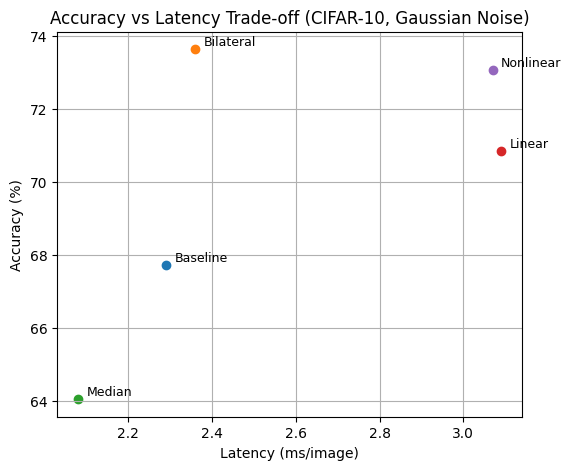

In [7]:
import matplotlib.pyplot as plt

# ===== 네 결과 입력 =====
methods = ["Baseline", "Bilateral", "Median", "Linear", "Nonlinear"]

accuracy = [67.74, 73.64, 64.05, 70.85, 73.08]  # gaussian 기준
latency = [2.29, 2.36, 2.08, 3.09, 3.07]

plt.figure(figsize=(6,5))

for i, m in enumerate(methods):
    plt.scatter(latency[i], accuracy[i])
    plt.text(latency[i]+0.02, accuracy[i]+0.1, m, fontsize=9)

plt.xlabel("Latency (ms/image)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Latency Trade-off (CIFAR-10, Gaussian Noise)")
plt.grid(True)

plt.savefig("accuracy_latency_plot.png", dpi=300)
plt.show()

NameError: name 'ALPHA_LIST' is not defined

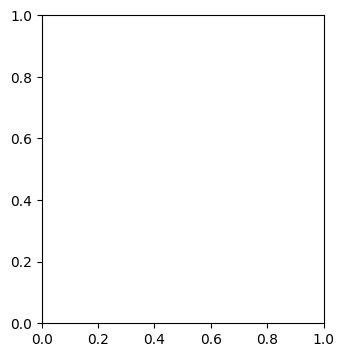

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# alpha
plt.subplot(1,2,1)
plt.plot(ALPHA_LIST, alpha_scores, marker='o')
plt.xlabel("alpha")
plt.ylabel("Accuracy (%)")
plt.title("Alpha Sensitivity")
plt.grid(True)

# gamma
plt.subplot(1,2,2)
plt.plot(GAMMA_LIST, gamma_scores, marker='o')
plt.xlabel("gamma")
plt.ylabel("Accuracy (%)")
plt.title("Gamma Sensitivity")
plt.grid(True)

plt.tight_layout()
plt.savefig("figure/alpha_gamma_sensitivity.png", dpi=300)
plt.close()